In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('/home/kyomukama/ACE/camonet/ML/ML clinical outcomes data 14.02.25 version 2  - Sheet1.csv')

In [4]:
data.describe()

,age,organism_isolated,length_hosp_stay
count,598.000000,324.000000,596.000000
mean,30.272575,1.203704,22.578859
std,22.906648,0.432988,39.681067
min,0.000000,1.000000,0.000000
25%,12.000000,1.000000,6.000000
50%,28.000000,1.000000,14.000000
75%,44.000000,1.000000,27.000000
max,95.000000,3.000000,744.000000


In [5]:
data.head()

,sion,age,sex,Infection_Site_1,Infection_Site_2,Infection_Site_3,referral,ward,antib_prior_admi,Prio_antib_1,...,first_organism,sec_organism,third_organism,Resistance,antib_aft_culture,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,complications,treatment_outcome,length_hosp_stay
0,Arua,6.0,Male,Brain,NaN,NaN,Yes,Pediatric ward,Unknown,NaN,...,NaN,NaN,NaN,No,NaN,NaN,NaN,No,Cured/recovered,12.0
1,Arua,13.0,Male,Lungs,Systemic,NaN,Yes,Medical ward,Unknown,NaN,...,NaN,NaN,NaN,No,NaN,NaN,NaN,No,Cured/recovered,8.0
2,Arua,11.0,Male,Systemic,NaN,NaN,No,Pediatric ward,Unknown,NaN,...,NaN,NaN,NaN,No,NaN,NaN,NaN,Yes,Cured/recovered,14.0
3,Arua,18.0,Male,Surgical_site,NaN,NaN,Yes,Surgical ward,Unknown,NaN,...,Citrobacter spp,NaN,NaN,Yes,No,NaN,NaN,Yes,Cured/recovered,0.0
4,Arua,17.0,Female,Surgical_site,NaN,NaN,Yes,Maternity ward,Unknown,NaN,...,Escherichia coli,NaN,NaN,Yes,Yes,Chloramphenicol,NaN,Yes,Cured/recovered,10.0


In [6]:
data.rename(columns = {'sion': 'name_of_rrh'}, inplace = True)

In [7]:
data.columns

Index(['name_of_rrh', 'age', 'sex', 'Infection_Site_1', 'Infection_Site_2',
       'Infection_Site_3', 'referral', 'ward', 'antib_prior_admi',
       'Prio_antib_1', 'Prio_antib_2', 'Prio_antib_3', 'Prio_antib_4',
       'sympt_dura', 'hiv_status', 'intubated', 'cormobid_condition',
       'antibiotics', 'Prescribed_antib_1', 'Prescribed_antib_2',
       'Prescribed_antib_3', 'Prescribed_antib_4', 'Prescribed_antib_5',
       'organism_isolated', 'growth1', 'first_organism', 'sec_organism',
       'third_organism', 'Resistance', 'antib_aft_culture',
       'Antibioitic_aft_cul_1', 'Antibioitic_aft_cul_2', 'complications',
       'treatment_outcome', 'length_hosp_stay'],
      dtype='object')

# EDA

In [8]:
data.shape

(599, 35)

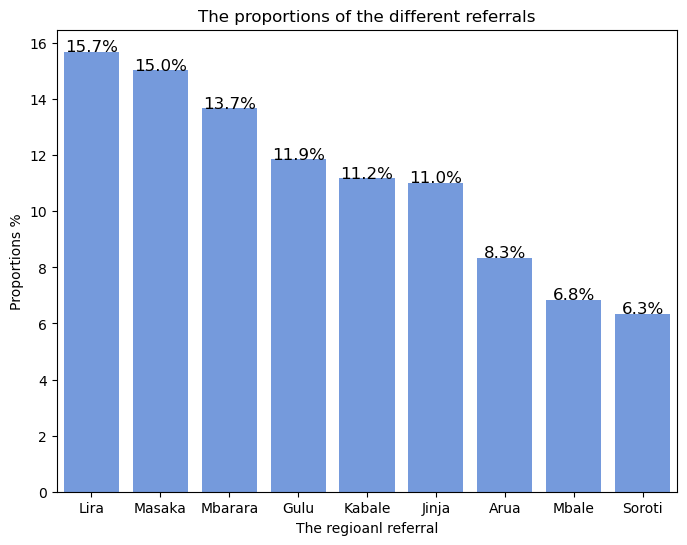

In [9]:
referral_count = data['name_of_rrh'].value_counts(normalize = True) * 100

plt.figure(figsize = (8,6))

ax = sns.barplot(x = referral_count.index, y = referral_count.values, color = 'cornflowerblue')

plt.title("The proportions of the different referrals")
plt.xlabel('The regioanl referral')
plt.ylabel("Proportions %")

# Show percentage values on bars
for i, val in enumerate(referral_count.values):
    plt.text(i, val, f"{val:.1f}%", ha='center', fontsize=12)
    

plt.show()

In [10]:
data['age'].describe()

count    598.000000
mean      30.272575
std       22.906648
min        0.000000
25%       12.000000
50%       28.000000
75%       44.000000
max       95.000000
Name: age, dtype: float64

In [11]:
data[data['age'].isna()].index

Index([567], dtype='int64')

In [12]:
data['age'] = data['age'].fillna(data['age'].median())

Text(0.5, 1.0, 'Age distribution')

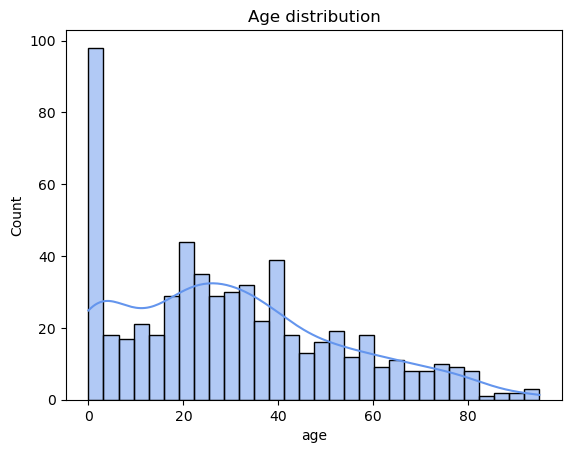

In [13]:
sns.histplot(data, x= 'age', bins = 30, kde = True, color = 'cornflowerblue')

plt.title("Age distribution")

In [14]:
data['sex'].info

<bound method Series.info of 0        Male
1        Male
2        Male
3        Male
4      Female
        ...  
594    Female
595    Female
596    Female
597    Female
598    Female
Name: sex, Length: 599, dtype: object>

/tmp/ipykernel_8540/332617357.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(x = sex_count.index, y = sex_count.values, palette = 'Set1')


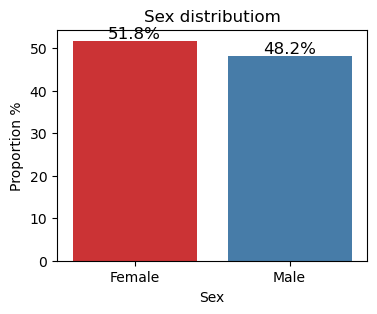

In [15]:
sex_count = data['sex'].value_counts(normalize = True)* 100

plt.figure(figsize = (4,3))

ax =sns.barplot(x = sex_count.index, y = sex_count.values, palette = 'Set1')

plt.title('Sex distributiom')
plt.xlabel('Sex')
plt.ylabel('Proportion %')

# Show percentage values on bars
for i, val in enumerate(sex_count.values):
    plt.text(i, val + 0.5, f"{val:.1f}%", ha='center', fontsize=12)

plt.show()

<Axes: xlabel='name_of_rrh', ylabel='age'>

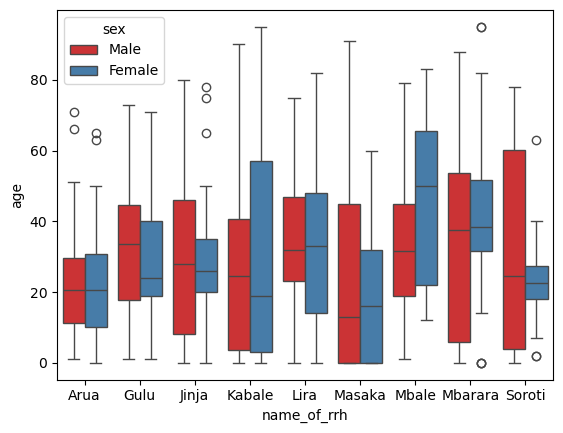

In [16]:
sns.boxplot(data, x= 'name_of_rrh', y = 'age', hue = 'sex', palette= 'Set1')

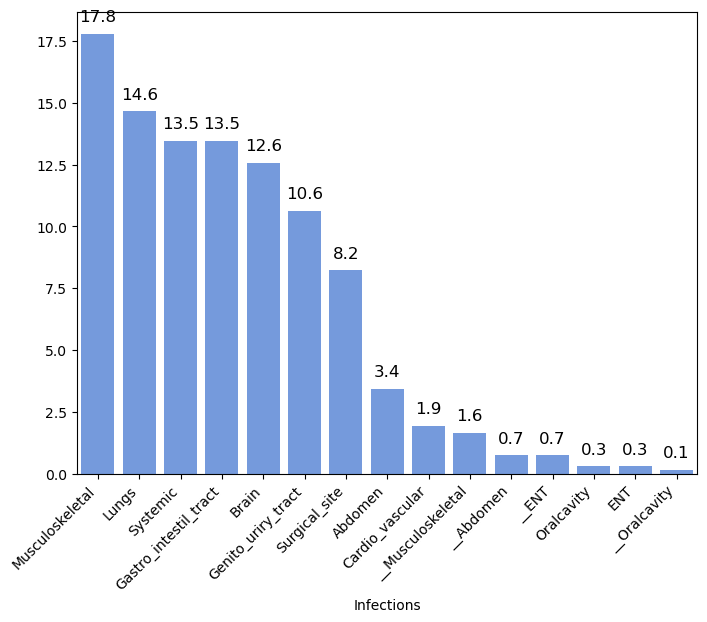

In [17]:
infection = pd.melt(
    data,
    id_vars = 'ward',
    value_vars= ['Infection_Site_1', 'Infection_Site_2', 'Infection_Site_3'],
    value_name= 'Infections'
)

infection.dropna(subset = 'Infections')

plt.figure(figsize = (8,6))

infection_count = infection['Infections'].value_counts(normalize = True)* 100

sns.barplot(x = infection_count.index , y = infection_count.values , color = 'cornflowerblue')

plt.xticks(rotation = 45, ha = 'right')

# Show percentage values on bars
for i, val in enumerate(infection_count.values):
    plt.text(i, val + 0.5, f"{val:.1f}", ha='center', fontsize=12)

plt.show()

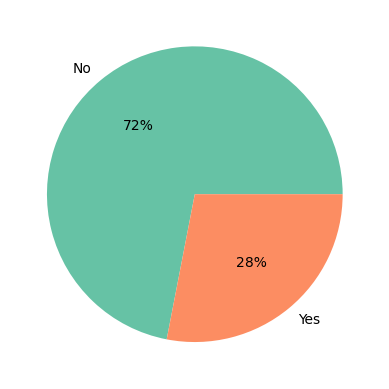

In [18]:
# define Seaborn color palette to use 
palette_color = sns.color_palette('Set2') 
referral_count =  data['referral'].value_counts(normalize = True)*100
  
# plotting data on chart 
plt.pie(referral_count.values, labels= referral_count.index, colors=palette_color, autopct='%.0f%%') 
  
# displaying chart 
plt.show() 

<function matplotlib.pyplot.show(close=None, block=None)>

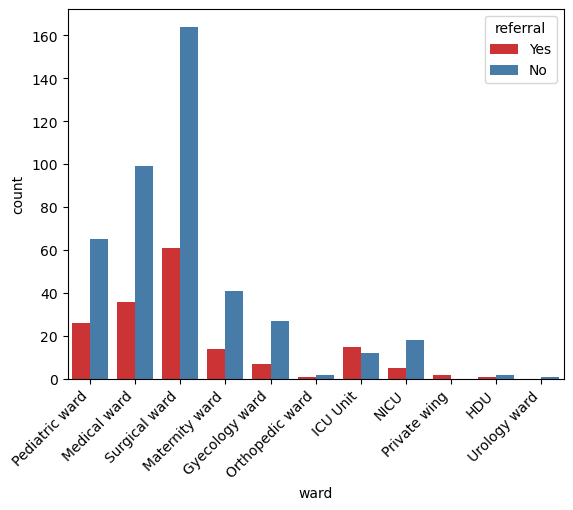

In [19]:
sns.countplot(data, x = 'ward', hue = 'referral', palette = 'Set1')

plt.xticks(rotation = 45, ha ='right')

plt.show

<Axes: xlabel='referral', ylabel='length_hosp_stay'>

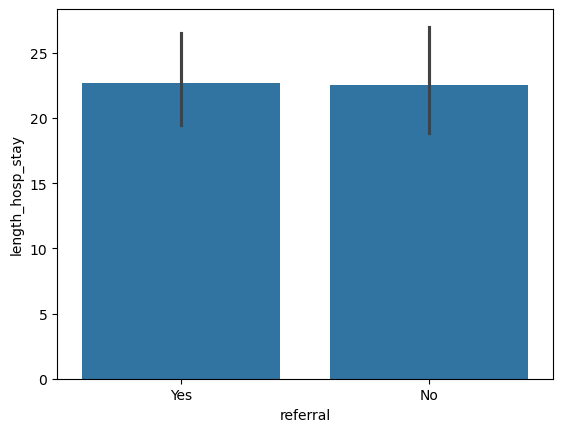

In [20]:
sns.barplot(data, x= 'referral', y = 'length_hosp_stay')

<Axes: xlabel='hiv_status', ylabel='length_hosp_stay'>

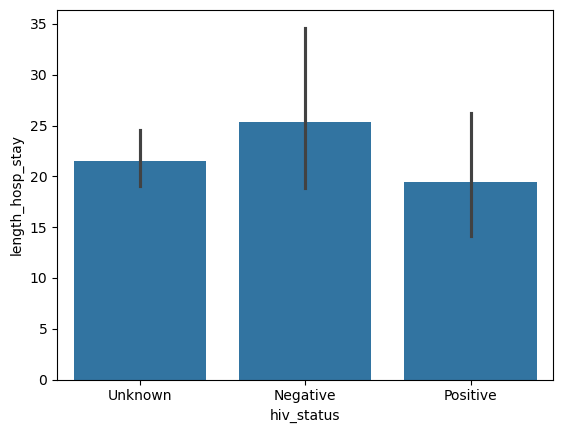

In [21]:
sns.barplot(data, x= 'hiv_status', y = 'length_hosp_stay')

In [22]:
data['intubated'] = data['intubated'].replace({'Unknown': 'No'})

<Axes: xlabel='intubated', ylabel='length_hosp_stay'>

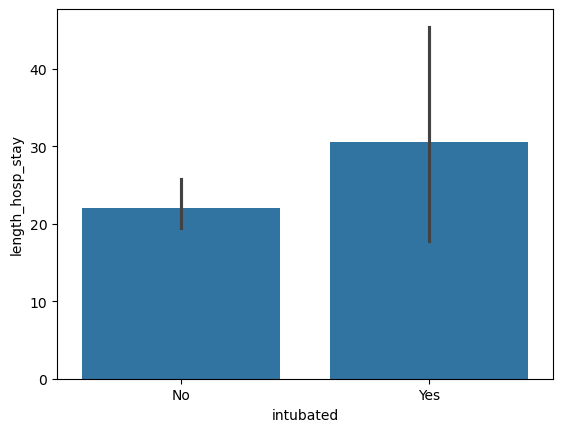

In [23]:
sns.barplot(data, x= 'intubated', y = 'length_hosp_stay')

In [24]:
def check_prior_antibiotics(row):
    for col in ['Prio_antib_1', 'Prio_antib_2', 'Prio_antib_3', 'Prio_antib_4']:
        if pd.notna(row[col]):  # Check if the value is not NaN/None
            return 'Yes'
    return 'No'


# Create the new 'Prio_antib' column
data['Prio_antib'] = data.apply(check_prior_antibiotics, axis=1)

In [25]:
# drop the other columns of rior antibiotic use

data.drop(columns = ['Prio_antib_1', 'Prio_antib_2', 'Prio_antib_3', 'Prio_antib_4'], inplace = True, axis = 1)

In [26]:
# def resitance_check (row) :
#     if any(row[['Resistance1 ', 'Resistance2', 'Resistance3']] =='Yes'):
#         return 'Yes'
#     else:
#         return 'No'
    
# # Create a new column 'resistance' using the function
# data['resistance'] = data.apply(resitance_check, axis=1)

<Axes: xlabel='Resistance', ylabel='length_hosp_stay'>

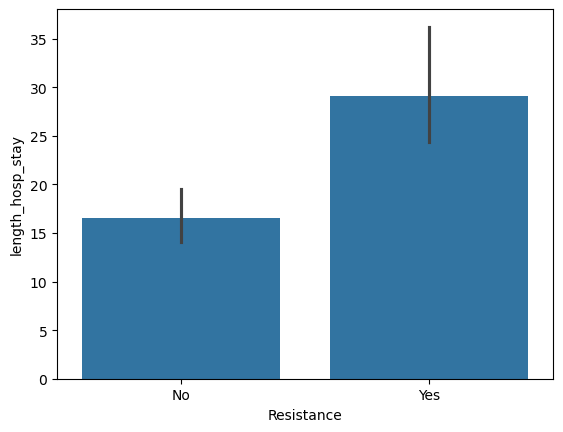

In [27]:
sns.barplot(data, x= 'Resistance', y = 'length_hosp_stay')

In [28]:
#data.drop(columns =['growth1'], inplace= True)

# Filling missingness

## Infections sites

In [29]:
def infection_missing(df) :
    for col in ['Infection_Site_1', 'Infection_Site_2', 'Infection_Site_3']:
        if pd.isna(df[col]):
            df[col] = 'No infection'
    return df

data = data.apply(infection_missing, axis = 1)

## Prio antibiotics taken

In [30]:
# def prio_antib_missing(df) :
#     for col in ['Prio_antib_1', 'Prio_antib_2', 'Prio_antib_3', 'Prio_antib_4']:
#         if pd.isna(df[col]):
#             df[col] = 'UNK'
#     return df

# data = data.apply(prio_antib_missing, axis = 1)

## Cormobidity

In [31]:
# def cormobidity_missing(df) :
#     for col in ['Comobidity1', 'Comobidity2', 'Comobidity3']:
#         if pd.isna(df[col]):
#             df[col] = 'UNK'
#     return df

# data = data.apply(cormobidity_missing, axis = 1)

## Antibiotic prescribed

In [32]:
def Prescribed_antib_missing(df) :
    for col in ['Prescribed_antib_1', 'Prescribed_antib_2', 'Prescribed_antib_3', 'Prescribed_antib_4', 'Prescribed_antib_5']:
        if pd.isna(df[col]):
            df[col] = 'No antibiotic prescribed'
    return df

data = data.apply(Prescribed_antib_missing, axis = 1)

## Pathogens

In [33]:
def pathogen_missing(df) :
    for col in ['first_organism', 'sec_organism', 'third_organism']:
        if pd.isna(df[col]):
            df[col] = 'No pathogen'
    return df

data = data.apply(pathogen_missing, axis = 1)

## Antibiotics after culture

In [34]:
def antib_aft_missing(df) :
    for col in ['Antibioitic_aft_cul_1', 'Antibioitic_aft_cul_2']:
        if pd.isna(df[col]):
            df[col] = 'No antibiotic precibed'
    return df

data = data.apply(antib_aft_missing, axis = 1)

## antibiotics

In [35]:
def Antibiotics(df) :
    for col in ['antibiotics']:
        if pd.isna(df[col]):
            df[col] = 'No'
    return df

data = data.apply(Antibiotics, axis = 1)

## antibiotics after culture (Yes/No)

In [36]:
def Antibiotics_aft(df) :
    for col in ['antib_aft_culture']:
        if pd.isna(df[col]):
            df[col] = 'No'
    return df

data = data.apply(Antibiotics_aft, axis = 1)

## Complications

In [37]:
def Complications(df) :
    for col in ['complications']:
        if pd.isna(df[col]):
            df[col] = 'No'
    return df

data = data.apply(Complications, axis = 1)

## length of hospital stay

In [38]:
data.dropna(subset = 'length_hosp_stay', inplace = True)

# Encoding data

## Label Encoding

In [39]:
from sklearn.preprocessing import LabelEncoder

Le = LabelEncoder()

In [40]:
columns_to_encode = data.drop(columns = ['age', 'length_hosp_stay', 'referral', 'sex', 'intubated', 'antibiotics', 'Resistance', 'antib_aft_culture', 'complications'])

for column in columns_to_encode:
    data[column] = Le.fit_transform(data[column])

## One hot encoding

In [41]:
#sex
data['sex'] = data['sex'].replace({'Male': 0, 'Female': 1})

/tmp/ipykernel_8540/1529081699.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['sex'] = data['sex'].replace({'Male': 0, 'Female': 1})


In [42]:
data = data.replace ({'Yes': 1, "No": 0})

/tmp/ipykernel_8540/2147984969.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace ({'Yes': 1, "No": 0})


In [43]:
data.tail()

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,Infection_Site_3,referral,ward,antib_prior_admi,sympt_dura,...,sec_organism,third_organism,Resistance,antib_aft_culture,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,complications,treatment_outcome,length_hosp_stay,Prio_antib
594,8,2.0,1,7,4,2,0,7,1,2,...,10,3,0,0,15,10,0,0,10.0,0
595,8,27.0,1,10,4,2,0,3,2,2,...,10,3,1,0,15,10,0,0,3.0,1
596,8,20.0,1,10,4,2,0,3,1,2,...,10,3,0,0,15,10,0,0,6.0,0
597,8,24.0,1,10,4,2,1,3,1,4,...,10,3,0,0,15,10,0,1,8.0,0
598,8,2.0,1,6,4,2,0,7,1,2,...,10,3,1,1,7,6,0,0,21.0,0


# Correlation 

Correaltion with the target variable and also how the different variable correlate with each other

/tmp/ipykernel_8540/848355969.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='RdBu')


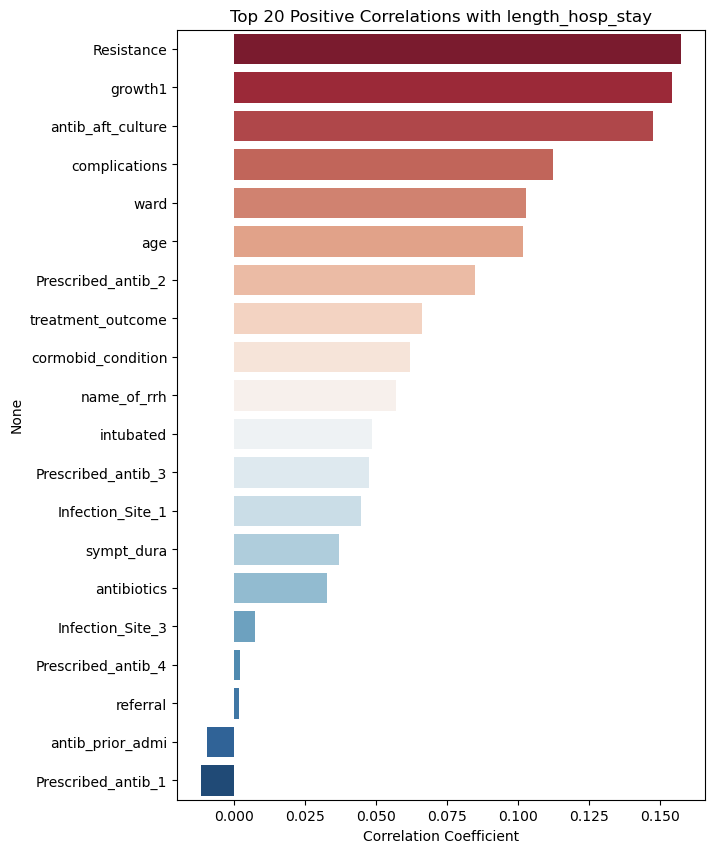

In [44]:
def plot_correlations(df, target_column, n_top = 39):
    
    # Calculate correlations with target variable
    correlations = df.corr()[target_column].sort_values(ascending=False)
    
    # Get top N most correlated features (excluding the target itself)
    top_corr = correlations[1:n_top+1]
    
    # Create figure with two subplots
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Horizontal bar chart of top correlations
    plt.subplot(1, 2, 1)
    sns.barplot(x=top_corr.values, y=top_corr.index, palette='RdBu')
    plt.title(f'Top {n_top} Positive Correlations with {target_column}')
    plt.xlabel('Correlation Coefficient')

plot_correlations(data, 'length_hosp_stay', n_top=20)

<Figure size 1500x1000 with 0 Axes>

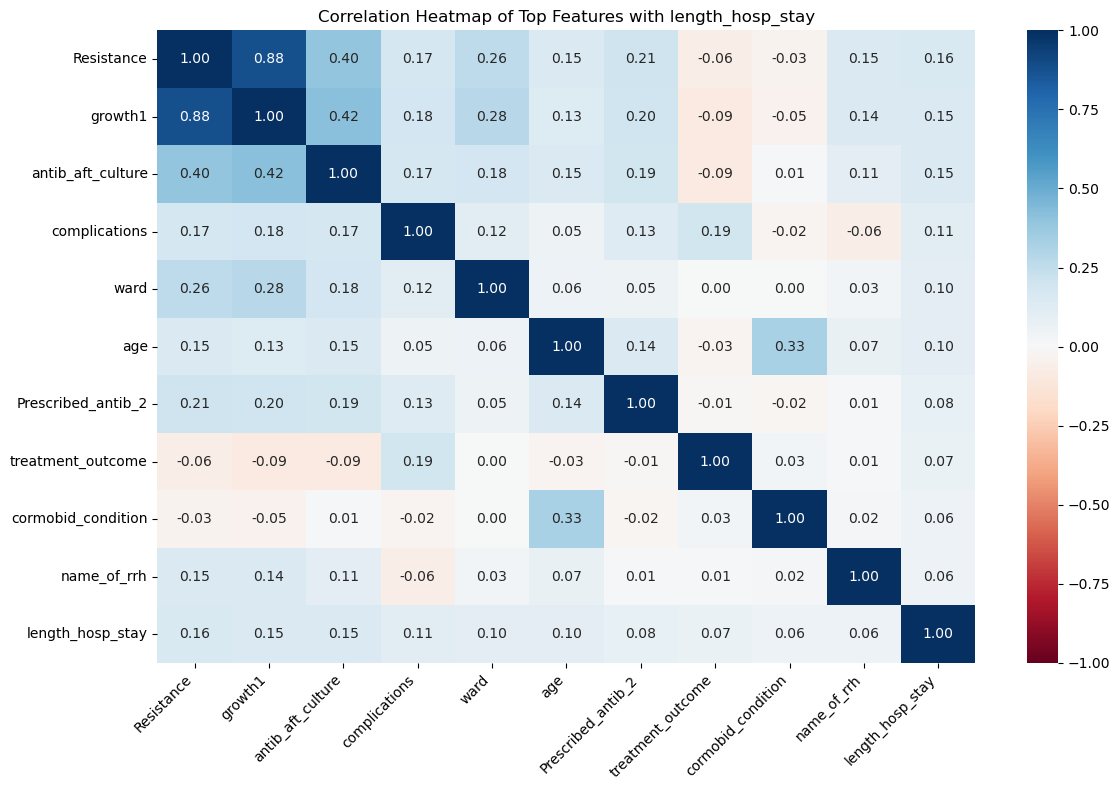

In [45]:
def plot_correlations(df, target_column, n_top=20):
    
    # Calculate correlations with target variable
    correlations = df.corr()[target_column].sort_values(ascending=False)
    
    # Get top N most correlated features (excluding the target itself)
    top_corr = correlations[1:n_top+1]
    #bottom_corr = correlations[-(n_top):]
    
    # Create figure with two subplots
    plt.figure(figsize=(15, 10))
    
    # Create heatmap of top correlated features
    plt.figure(figsize=(12, 8))
    top_features = list(top_corr.index[:10]) + [target_column]  # Top 10 + target
    correlation_matrix = df[top_features].corr()
    
    sns.heatmap(correlation_matrix, 
                annot=True,
                cmap='RdBu',
                vmin=-1, 
                vmax=1,
                center=0,
                fmt='.2f')
    plt.title(f'Correlation Heatmap of Top Features with {target_column}')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_correlations(data, 'length_hosp_stay', n_top=20)

# ML

## Data

In [46]:
growth = data[data['growth1']==1]

print(growth.shape)

growth.head()

(324, 32)


,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,Infection_Site_3,referral,ward,antib_prior_admi,sympt_dura,...,sec_organism,third_organism,Resistance,antib_aft_culture,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,complications,treatment_outcome,length_hosp_stay,Prio_antib
3,0,18.0,0,10,4,2,1,9,1,2,...,10,3,1,0,15,10,1,1,0.0,0
4,0,17.0,1,10,4,2,1,3,1,2,...,10,3,1,1,6,10,1,1,10.0,0
5,0,29.0,0,7,4,2,1,9,1,0,...,12,0,1,1,11,10,0,1,69.0,0
8,0,50.0,1,9,4,2,1,9,1,0,...,10,3,1,0,15,10,0,2,5.0,0
11,0,30.0,1,7,4,2,0,6,1,3,...,10,3,1,0,15,10,0,0,45.0,0


In [47]:
growth.drop(columns = ['growth1'], inplace = True)

/tmp/ipykernel_8540/576020328.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  growth.drop(columns = ['growth1'], inplace = True)


In [48]:
growth.drop(columns = [
    'intubated', 
    'antibiotics', 
    'Infection_Site_3', 
    'Antibioitic_aft_cul_2',
    'Infection_Site_3',
    'third_organism',
    'Prescribed_antib_4',
    'Prescribed_antib_5'
], inplace = True)

/tmp/ipykernel_8540/1396506915.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  growth.drop(columns = [


In [49]:
growth.to_csv('Patients with growth.csv', index = False)

In [50]:
no_growth = data[data['growth1'] == 0]

print(no_growth.shape)

no_growth.head()

(272, 32)


,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,Infection_Site_3,referral,ward,antib_prior_admi,sympt_dura,...,sec_organism,third_organism,Resistance,antib_aft_culture,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,complications,treatment_outcome,length_hosp_stay,Prio_antib
0,0,6.0,0,1,4,2,1,7,1,2,...,10,3,0,0,15,10,0,1,12.0,0
1,0,13.0,0,6,6,2,1,4,1,0,...,10,3,0,0,15,10,0,1,8.0,0
2,0,11.0,0,11,4,2,0,7,1,2,...,10,3,0,0,15,10,1,1,14.0,0
6,0,8.0,1,1,4,2,0,7,1,0,...,10,3,0,0,15,10,0,1,6.0,0
7,0,10.0,1,11,4,2,1,7,1,4,...,10,3,0,0,15,10,0,1,11.0,0


In [54]:
from sklearn.model_selection import train_test_split

# Apply log transformation to the target variable
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modelling

# Huber model

In [55]:
import mlflow
from mlflow.models import infer_signature
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Define the model hyperparameters
params = {
    'epsilon': 1.75,
    'max_iter': 500,
    'alpha': 0.1
}

# Train the model
huber = HuberRegressor(**params)
huber.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = huber.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    artifact_path = '/home/kyomukama/ACE/camonet/ML'
    mlflow.sklearn.log_model(huber, "huber_model", artifact_path,signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay')
plt.tight_layout()
plt.show()

/home/kyomukama/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


IsADirectoryError: [Errno 21] Is a directory: '/home/kyomukama/ACE/camonet/ML'

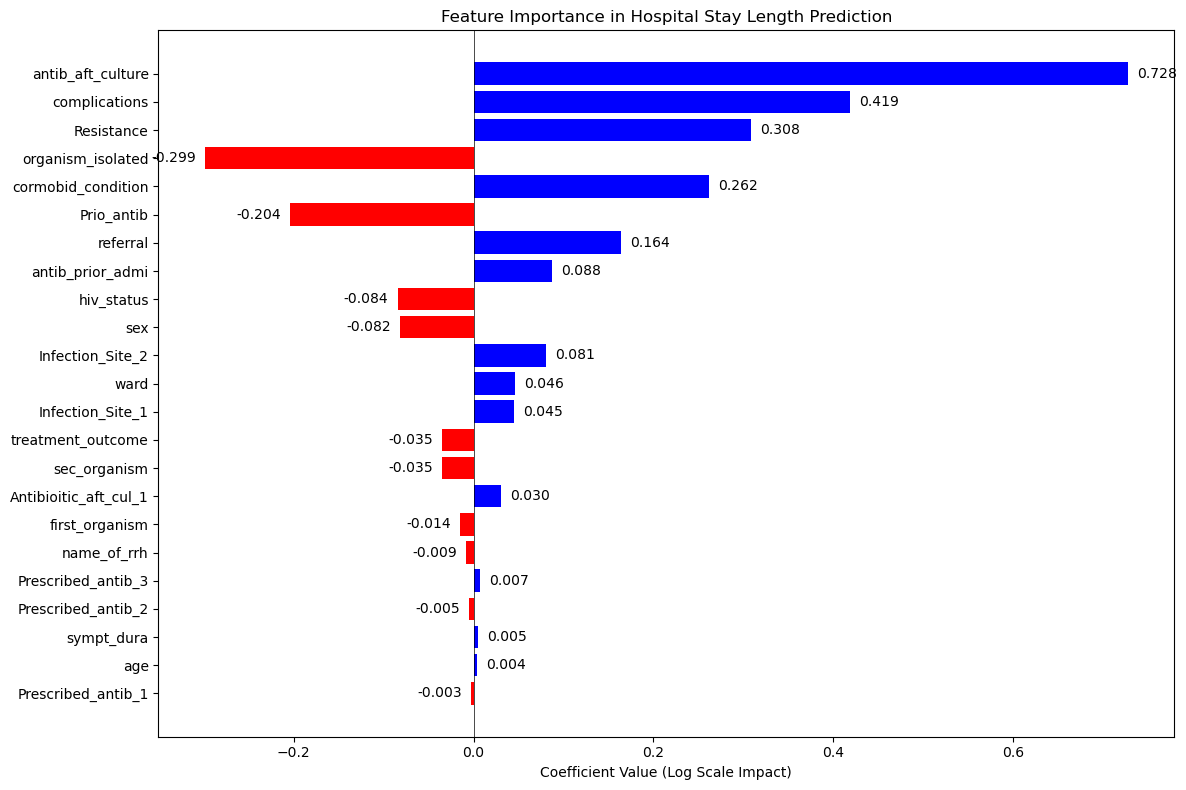


Feature Importance Rankings:
              feature  coefficient  abs_coefficient
    antib_aft_culture     0.727912         0.727912
        complications     0.419186         0.419186
           Resistance     0.308389         0.308389
    organism_isolated    -0.299035         0.299035
   cormobid_condition     0.262259         0.262259
           Prio_antib    -0.203845         0.203845
             referral     0.164159         0.164159
     antib_prior_admi     0.087579         0.087579
           hiv_status    -0.084430         0.084430
                  sex    -0.082000         0.082000
     Infection_Site_2     0.080796         0.080796
                 ward     0.046436         0.046436
     Infection_Site_1     0.045005         0.045005
    treatment_outcome    -0.035046         0.035046
         sec_organism    -0.034537         0.034537
Antibioitic_aft_cul_1     0.030306         0.030306
       first_organism    -0.014491         0.014491
          name_of_rrh    -0.008711

In [ ]:
# Get feature names and coefficients
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': huber.coef_
})

# Sort by absolute value of coefficient while keeping the sign
feature_importance['abs_coef'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coef', ascending=True)

# Create a horizontal bar plot
plt.figure(figsize=(12, 8))
colors = ['red' if c < 0 else 'blue' for c in feature_importance['coefficient']]
bars = plt.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)

# Add vertical line at x=0
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Customize the plot
plt.title('Feature Importance in Hospital Stay Length Prediction')
plt.xlabel('Coefficient Value (Log Scale Impact)')

# Add value labels on the bars
for bar in bars:
    width = bar.get_width()
    label_x = width + (0.01 if width >= 0 else -0.01)
    plt.text(label_x, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}',
             ha='left' if width >= 0 else 'right', 
             va='center')

plt.tight_layout()
plt.show()

# Print detailed feature importance table
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)
print("\nFeature Importance Rankings:")
print(feature_importance[['feature', 'coefficient', 'abs_coefficient']].to_string(index=False))

# Calculate percentage influence
total_importance = feature_importance['abs_coefficient'].sum()
feature_importance['influence_percentage'] = (feature_importance['abs_coefficient'] / total_importance * 100)

print("\nTop 5 Most Influential Features:")
top_5 = feature_importance.head()
for _, row in top_5.iterrows():
    direction = "increases" if row['coefficient'] > 0 else "decreases"
    print(f"{row['feature']}: {row['influence_percentage']:.1f}% influence ({direction} length of stay)")

In [ ]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow huber model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Huber model")

    # Infer the model signature
    signature = infer_signature(X_train, huber.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="Huber_model",
    )

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'Huber_model' already exists. Creating a new version of this model...
2025/02/27 15:27:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Mode

🏃 View run caring-swan-303 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/b3265ac965994d3891cede7d941e0716
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571


Created version '17' of model 'Huber_model'.


In [ ]:
# Load the model back for predictions as a generic Python Function model
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

predictions = loaded_model.predict(X_test)

dataset_names = growth.columns

result = pd.DataFrame(X_test, columns=dataset_names)
result["actual_class"] = y_test
result["predicted_class"] = predictions

result[:10]

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,referral,ward,antib_prior_admi,sympt_dura,hiv_status,...,sec_organism,Resistance,antib_aft_culture,Antibioitic_aft_cul_1,complications,treatment_outcome,length_hosp_stay,Prio_antib,actual_class,predicted_class
277,4,18.0,1,10,4,0,0,1,2,2,...,10,1,0,15,0,1,NaN,0,3.401197,2.500298
230,3,0.0,1,6,4,0,7,1,2,0,...,10,1,0,15,0,2,NaN,0,2.079442,2.636665
286,4,39.0,0,7,4,0,9,0,2,2,...,16,1,1,5,0,1,NaN,0,4.025352,2.630162
20,0,21.0,1,5,4,0,3,1,2,2,...,10,1,0,15,0,1,NaN,0,1.386294,2.359404
377,5,47.0,0,5,4,0,9,0,1,2,...,10,1,0,15,0,0,NaN,0,3.091042,2.876351
264,4,30.0,1,1,8,0,4,1,0,2,...,10,0,0,15,0,2,NaN,0,1.609438,2.083854
446,6,22.0,1,8,4,0,9,1,4,2,...,12,1,1,6,0,0,NaN,0,4.828314,2.575061
400,5,0.0,1,11,4,0,2,0,2,0,...,10,1,0,15,0,0,NaN,0,1.098612,2.433344
510,7,80.0,0,2,4,0,4,0,2,2,...,10,1,1,5,0,0,NaN,0,3.637586,2.750274
302,4,43.0,1,7,4,0,9,1,2,1,...,10,1,1,6,0,1,NaN,0,4.394449,3.422816


## Hyperparameter tuning

In [ ]:
import optuna

def objective(trial):
    """Function to optimize hyperparameters."""
    with mlflow.start_run():
        # Suggest hyperparameters
        epsilon = trial.suggest_float("epsilon", 1.1, 2.0)
        max_iter = trial.suggest_int("max_iter", 500, 2000, step=500)
        alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
        
        # Train the model
        model = HuberRegressor(epsilon=epsilon, max_iter=max_iter, alpha=alpha)
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Compute metric
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Log parameters and metrics to MLflow
        mlflow.log_params({"epsilon": epsilon, "max_iter": max_iter, "alpha": alpha})
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric('MSE', mse)
        mlflow.log_metric('R2', r2)

        return mae  # Optuna minimizes this

# Run optimization
study = optuna.create_study(direction="minimize")  # Minimize MAE
study.optimize(objective, n_trials=20)

# Print best parameters
print("Best parameters:", study.best_params)


[I 2025-02-27 15:27:48,435] A new study created in memory with name: no-name-8ad38021-a0d6-4a11-b7aa-9d88dc9b8b12


/tmp/ipykernel_5857/1007683687.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
[I 2025-02-27 15:27:49,417] Trial 0 finished with value: 0.7112003002346818 and parameters: {'epsilon': 1.1587590737914322, 'max_iter': 1500, 'alpha': 0.0003431859204070999}. Best is trial 0 with value: 0.7112003002346818.


🏃 View run righteous-midge-342 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/3c2a23aac76f464481018ff505031947
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571


/tmp/ipykernel_5857/1007683687.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
[I 2025-02-27 15:27:50,079] Trial 1 finished with value: 0.7061268078795823 and parameters: {'epsilon': 1.961959582884354, 'max_iter': 500, 'alpha': 2.5689777994022894e-05}. Best is trial 1 with value: 0.7061268078795823.


🏃 View run fun-finch-226 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/6e60f841b86847858034acfd04e10066
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571


...

🏃 View run valuable-doe-434 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/2eaef105fea340abb0aaf27ef2c0b506
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571


/tmp/ipykernel_5857/1007683687.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
[I 2025-02-27 15:28:05,338] Trial 18 finished with value: 0.7000980997544433 and parameters: {'epsilon': 1.5444887313599405, 'max_iter': 1500, 'alpha': 0.0010147815724353005}. Best is trial 11 with value: 0.7000273374021212.


🏃 View run mysterious-worm-351 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/7f60fb3519e34eab9cf3edc8a7faac6f
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571


/tmp/ipykernel_5857/1007683687.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
[I 2025-02-27 15:28:05,925] Trial 19 finished with value: 0.7089423593760756 and parameters: {'epsilon': 1.3017796294735573, 'max_iter': 1500, 'alpha': 0.00010392160163011008}. Best is trial 11 with value: 0.7000273374021212.


🏃 View run loud-ram-636 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/3cd1f7173b144ebeb09cc2cecc18ebeb
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571
Best parameters: {'epsilon': 1.5639349777911402, 'max_iter': 2000, 'alpha': 0.009686248934797852}


In [ ]:
# Load the model back for predictions as a generic Python Function model
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

predictions = loaded_model.predict(X_test)

dataset_names = growth.columns

result = pd.DataFrame(X_test, columns=dataset_names)
result["actual_class"] = y_test
result["predicted_class"] = predictions

result[:10]

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,referral,ward,antib_prior_admi,sympt_dura,hiv_status,...,sec_organism,Resistance,antib_aft_culture,Antibioitic_aft_cul_1,complications,treatment_outcome,length_hosp_stay,Prio_antib,actual_class,predicted_class
277,4,18.0,1,10,4,0,0,1,2,2,...,10,1,0,15,0,1,NaN,0,3.401197,2.500298
230,3,0.0,1,6,4,0,7,1,2,0,...,10,1,0,15,0,2,NaN,0,2.079442,2.636665
286,4,39.0,0,7,4,0,9,0,2,2,...,16,1,1,5,0,1,NaN,0,4.025352,2.630162
20,0,21.0,1,5,4,0,3,1,2,2,...,10,1,0,15,0,1,NaN,0,1.386294,2.359404
377,5,47.0,0,5,4,0,9,0,1,2,...,10,1,0,15,0,0,NaN,0,3.091042,2.876351
264,4,30.0,1,1,8,0,4,1,0,2,...,10,0,0,15,0,2,NaN,0,1.609438,2.083854
446,6,22.0,1,8,4,0,9,1,4,2,...,12,1,1,6,0,0,NaN,0,4.828314,2.575061
400,5,0.0,1,11,4,0,2,0,2,0,...,10,1,0,15,0,0,NaN,0,1.098612,2.433344
510,7,80.0,0,2,4,0,4,0,2,2,...,10,1,1,5,0,0,NaN,0,3.637586,2.750274
302,4,43.0,1,7,4,0,9,1,2,1,...,10,1,1,6,0,1,NaN,0,4.394449,3.422816


Fitting 5 folds for each of 25 candidates, totalling 125 fits


/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL N

Best parameters: {'alpha': 0.1, 'epsilon': 2.0, 'max_iter': 500}
Best cross-validation score (RMSE): 0.9636978860725652

Top 5 parameter combinations:
                                               params      rmse  \
24    {'alpha': 0.1, 'epsilon': 2.0, 'max_iter': 500}  0.963698   
19   {'alpha': 0.05, 'epsilon': 2.0, 'max_iter': 500}  0.963873   
4   {'alpha': 0.001, 'epsilon': 2.0, 'max_iter': 500}  0.963887   
9   {'alpha': 0.005, 'epsilon': 2.0, 'max_iter': 500}  0.963929   
14   {'alpha': 0.01, 'epsilon': 2.0, 'max_iter': 500}  0.963972   

    std_test_score  
24        0.094910  
19        0.095485  
4         0.095208  
9         0.095059  
14        0.095323  


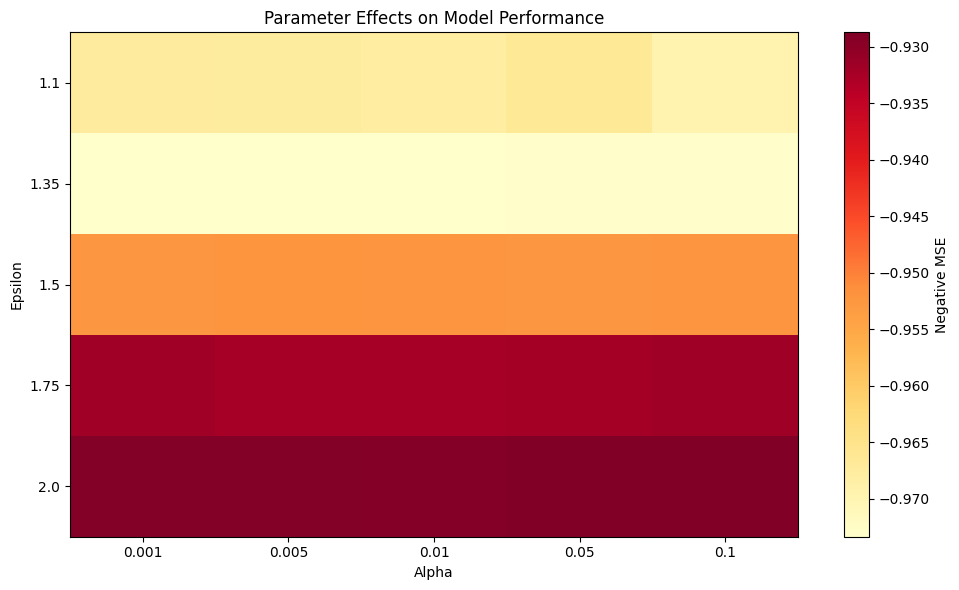


Feature Importances:
                  feature  coefficient
18      antib_aft_culture     0.698066
20          complications     0.407707
22             Prio_antib    -0.271900
17             Resistance     0.238531
10     cormobid_condition     0.237359
14      organism_isolated    -0.191220
5                referral     0.146993
7        antib_prior_admi     0.084598
2                     sex    -0.076462
4        Infection_Site_2     0.070033
21      treatment_outcome    -0.049934
3        Infection_Site_1     0.041070
6                    ward     0.038449
9              hiv_status    -0.029389
16           sec_organism    -0.021858
19  Antibioitic_aft_cul_1     0.018893
8              sympt_dura     0.015287
15         first_organism    -0.009799
1                     age     0.004855
13     Prescribed_antib_3     0.004134
0             name_of_rrh    -0.002855
11     Prescribed_antib_1     0.001950
12     Prescribed_antib_2    -0.001866


/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL N


Cross-validation RMSE scores:
Mean RMSE: 0.9624 (+/- 0.0992)


/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [ ]:
from sklearn.model_selection import GridSearchCV

# Prepare the data (using log transform as before)
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])

# Define parameter grid
param_grid = {
    'epsilon': [1.1, 1.35, 1.5, 1.75, 2.0],
    'alpha': [0.001, 0.005, 0.01, 0.05, 0.1],
    'max_iter': [500]  # Fixed as it's more of a computational parameter
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    HuberRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X, y)

# Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score (RMSE):", np.sqrt(-grid_search.best_score_))

# Get detailed results
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')

# Print top 5 parameter combinations
print("\nTop 5 parameter combinations:")
top_5 = cv_results[['params', 'mean_test_score', 'std_test_score']].head()
top_5['rmse'] = np.sqrt(-top_5['mean_test_score'])
print(top_5[['params', 'rmse', 'std_test_score']])

# Plot parameter effects
import matplotlib.pyplot as plt

# Create epsilon vs alpha heatmap
pivot_table = cv_results.pivot_table(
    values='mean_test_score',
    index='param_epsilon',
    columns='param_alpha'
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot_table, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Negative MSE')
plt.xticks(range(len(param_grid['alpha'])), param_grid['alpha'])
plt.yticks(range(len(param_grid['epsilon'])), param_grid['epsilon'])
plt.xlabel('Alpha')
plt.ylabel('Epsilon')
plt.title('Parameter Effects on Model Performance')
plt.tight_layout()
plt.show()

# Train final model with best parameters
best_model = HuberRegressor(**grid_search.best_params_)
best_model.fit(X, y)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_model.coef_
})
feature_importance = feature_importance.sort_values('coefficient', key=abs, ascending=False)

print("\nFeature Importances:")
print(feature_importance)

# Validate the model using cross-validation scores
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores)

print("\nCross-validation RMSE scores:")
print(f"Mean RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std() * 2:.4f})")

# Random Forest Regressor


/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run monumental-stag-716 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/605c44f6dabc48d6a4afdd6c73619540
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571
Mean Absolute Error: 15.40
Root Mean Squared Error: 25.80
R-squared Score: 0.0745


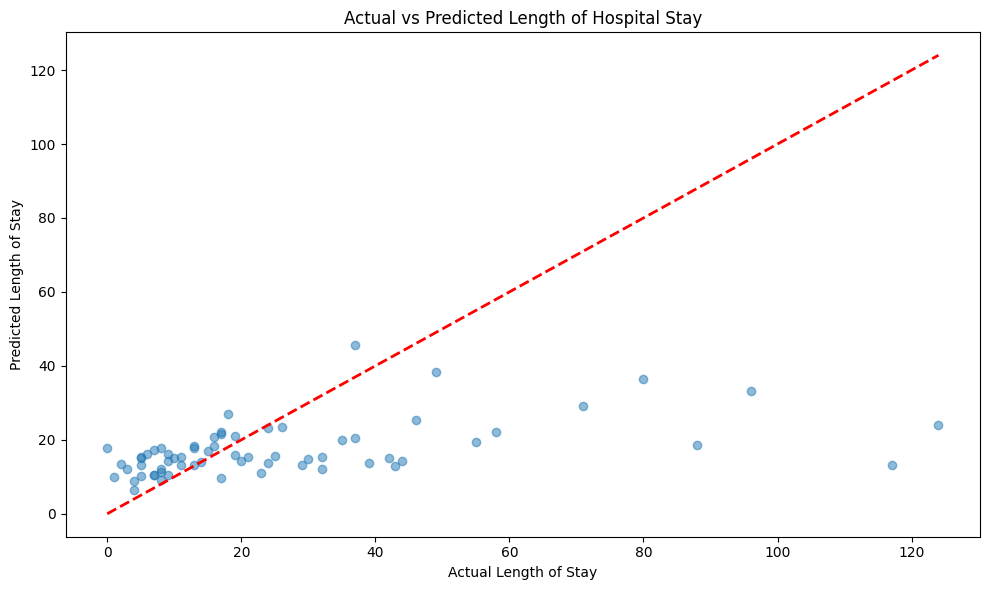

In [ ]:
import mlflow
from mlflow.models import infer_signature
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Apply log transformation to the target variable
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters
params = {
    'random_state':10,
    'n_estimators': 1250, 
    'min_samples_split': 10, 
    'min_samples_leaf': 4, 
    'max_features': 0.7, 
    'max_depth': 20, 
    'bootstrap': True
}

rf = RandomForestRegressor(**params)
rf.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(rf, "Rf_regressor_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay')
plt.tight_layout()
plt.show()

In [ ]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow RandomForest Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Random Forest Regressor model")

    # Infer the model signature
    signature = infer_signature(X_train, rf.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="RandomForest Regressor model",
    )

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Registered model 'RandomForest Regressor model' already exists. Creating a new version of this model...
2025/02/27 15:29:13 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RandomForest Regressor model, version 14
Created version '14' of model 'RandomForest Regressor model'.


🏃 View run dapper-foal-724 at: http://127.0.0.1:8080/#/experiments/320510952361426209/runs/b703f34d3da146f98f5cf1e766f28f63
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/320510952361426209


In [ ]:
# Load the model back for predictions as a generic Python Function model
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

predictions = loaded_model.predict(X_test)

dataset_names = growth.columns

result = pd.DataFrame(X_test, columns=dataset_names)
result["actual_class"] = y_test
result["predicted_class"] = predictions

result[:10]

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,referral,ward,antib_prior_admi,sympt_dura,hiv_status,...,sec_organism,Resistance,antib_aft_culture,Antibioitic_aft_cul_1,complications,treatment_outcome,length_hosp_stay,Prio_antib,actual_class,predicted_class
277,4,18.0,1,10,4,0,0,1,2,2,...,10,1,0,15,0,1,NaN,0,3.401197,2.500298
230,3,0.0,1,6,4,0,7,1,2,0,...,10,1,0,15,0,2,NaN,0,2.079442,2.636665
286,4,39.0,0,7,4,0,9,0,2,2,...,16,1,1,5,0,1,NaN,0,4.025352,2.630162
20,0,21.0,1,5,4,0,3,1,2,2,...,10,1,0,15,0,1,NaN,0,1.386294,2.359404
377,5,47.0,0,5,4,0,9,0,1,2,...,10,1,0,15,0,0,NaN,0,3.091042,2.876351
264,4,30.0,1,1,8,0,4,1,0,2,...,10,0,0,15,0,2,NaN,0,1.609438,2.083854
446,6,22.0,1,8,4,0,9,1,4,2,...,12,1,1,6,0,0,NaN,0,4.828314,2.575061
400,5,0.0,1,11,4,0,2,0,2,0,...,10,1,0,15,0,0,NaN,0,1.098612,2.433344
510,7,80.0,0,2,4,0,4,0,2,2,...,10,1,1,5,0,0,NaN,0,3.637586,2.750274
302,4,43.0,1,7,4,0,9,1,2,1,...,10,1,1,6,0,1,NaN,0,4.394449,3.422816



Feature Importance with Best Parameters:
                  feature  importance
1                     age    0.172912
21      treatment_outcome    0.116480
18      antib_aft_culture    0.090315
15         first_organism    0.069757
3        Infection_Site_1    0.069415
0             name_of_rrh    0.067209
20          complications    0.053007
11     Prescribed_antib_1    0.045941
12     Prescribed_antib_2    0.045783
6                    ward    0.037023
19  Antibioitic_aft_cul_1    0.029868
9              hiv_status    0.026734
8              sympt_dura    0.026024
16           sec_organism    0.024317
10     cormobid_condition    0.020737
13     Prescribed_antib_3    0.019886
2                     sex    0.019277
7        antib_prior_admi    0.016704
5                referral    0.014273
14      organism_isolated    0.014252
4        Infection_Site_2    0.010623
17             Resistance    0.006365
22             Prio_antib    0.003097


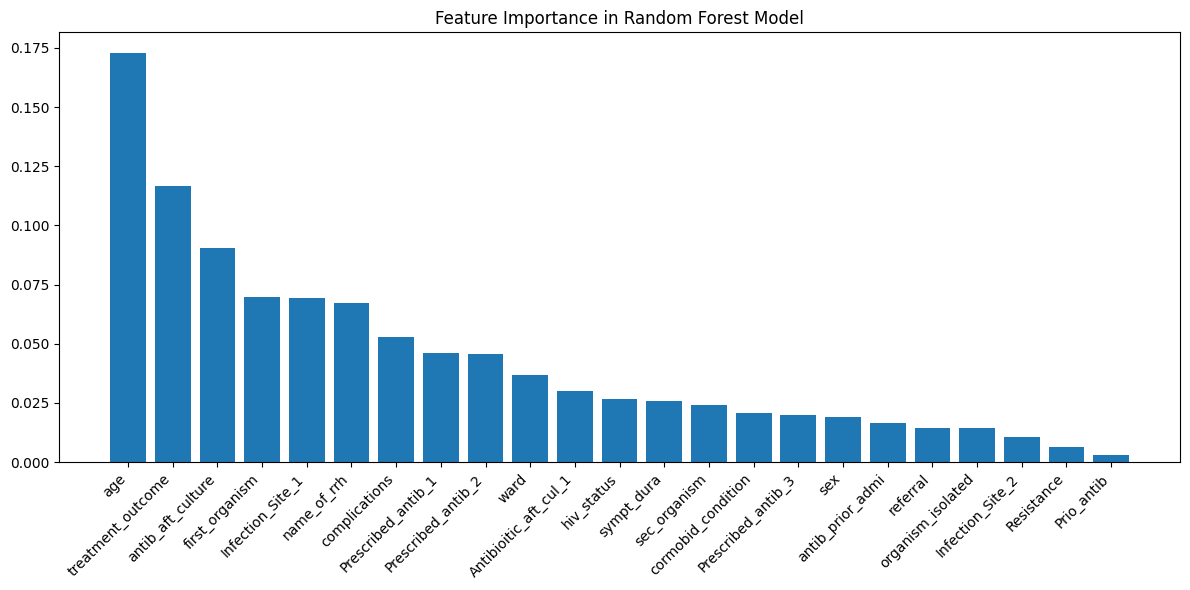

In [ ]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\nFeature Importance with Best Parameters:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(12, 6))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance in Random Forest Model')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error
import pandas as pd

# Prepare the data
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])

# Define custom scorer for original scale RMSE
def custom_rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))

rmse_scorer = make_scorer(custom_rmse_scorer, greater_is_better=False)

# Define parameter distributions
param_dist = {
    'n_estimators': [500, 750, 1000, 1250],
    'max_features': [0.6, 0.7, 0.8, 0.9],
    'min_samples_split': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_depth': [None, 10, 20, 30],
    'bootstrap': [True, False]
}

# Create Random Forest model
rf = RandomForestRegressor(random_state=1)

# Perform randomized search
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring=rmse_scorer,
    n_jobs=-1,
    random_state=1,
    verbose=1
)

# Fit the random search
random_search.fit(X, y)

# Print results
print("Best parameters found:")
print(random_search.best_params_)
print("\nBest RMSE:", -random_search.best_score_)

# Get all results
results = pd.DataFrame(random_search.cv_results_)
results = results.sort_values('mean_test_score', ascending=False)

# Print top 5 combinations
print("\nTop 5 parameter combinations:")
for i in range(5):
    params = results.iloc[i]['params']
    score = -results.iloc[i]['mean_test_score']
    std = results.iloc[i]['std_test_score']
    print(f"\nRank {i+1}:")
    print(f"Parameters: {params}")
    print(f"RMSE: {score:.2f} (+/- {std*2:.2f})")

# Train best model and get feature importance
best_model = RandomForestRegressor(**random_search.best_params_, random_state=1)
best_model.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Best parameters found:
{'n_estimators': 1250, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': True}

Best RMSE: 38.7258990105586

Top 5 parameter combinations:

Rank 1:
Parameters: {'n_estimators': 1250, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': True}
RMSE: 38.73 (+/- 57.37)

Rank 2:
Parameters: {'n_estimators': 1000, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 0.9, 'max_depth': 30, 'bootstrap': True}
RMSE: 38.75 (+/- 57.24)

Rank 3:
Parameters: {'n_estimators': 1000, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 0.8, 'max_depth': 30, 'bootstrap': True}
RMSE: 38.78 (+/- 57.18)

Rank 4:
Parameters: {'n_estimators': 500, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 0.6, 'max_depth': None, 'bootstrap': True}
RMSE: 38.78 (+/- 57.34)

Rank 5:
Parameters: {'n_estimators': 750, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_feat

RandomForestRegressor(max_depth=20, max_features=0.7, min_samples_leaf=4,
                      min_samples_split=10, n_estimators=1250, random_state=1)

# GradientBoostingRegressor

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run tasteful-penguin-224 at: http://127.0.0.1:8080/#/experiments/320510952361426209/runs/7a62e61e013041638913f44503ac53d0
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/320510952361426209
Mean Absolute Error: 15.81
Root Mean Squared Error: 24.76
R-squared Score: 0.1477


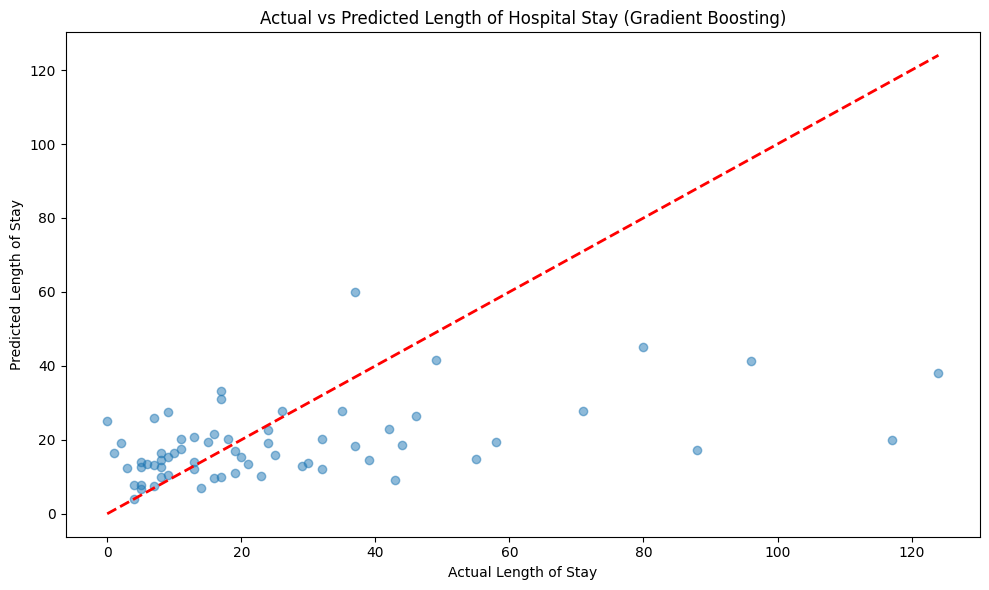

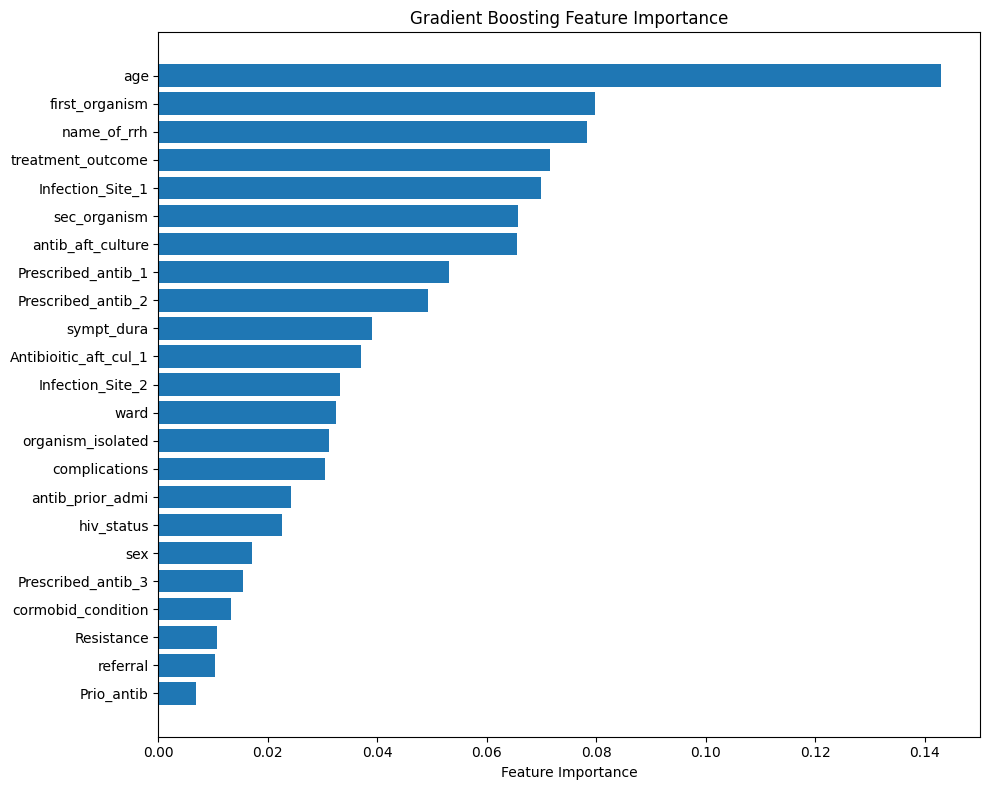

In [ ]:
import mlflow
from mlflow.models import infer_signature
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Apply log transformation to the target variable
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters for Gradient Boosting
params = {
    'random_state': 10,
    'n_estimators': 3000,         # Significantly increased for better fit
    'learning_rate': 0.008751328233611147,       # Further reduced for more precise corrections
    'max_depth': 8,               # Increased to capture more complex patterns
    'min_samples_split': 2,       # Minimum value to create highly specialized trees
    'min_samples_leaf': 1,        # Minimum value for maximum tree detail
    'subsample': 0.7135681866731614,            # Increased to use more of the training data
    'max_features': 0.6975751180009072,          # Using most features for splits
    'loss': 'ls',      # Direct optimization for MSE
    'validation_fraction': 0.2,   # For early stopping
    'n_iter_no_change': 100,      # For early stopping
    'tol': 1e-5                   # For early stopping
}

# {
#     'learning_rate': 0.008751328233611147,
#     'loss': 'ls', 
#     'max_depth': 4, 
#     'max_features': 0.6975751180009072, 
#     'min_samples_leaf': 4, 
#     'min_samples_split': 9, 
#     'n_estimators': 2275, 
#     'subsample': 0.7135681866731614
#     }


# Initialize and train the Gradient Boosting Regressor
gb = GradientBoostingRegressor(**params)
gb.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = gb.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(gb, "GB_regressor_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
          [y_test_original.min(), y_test_original.max()],
          'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Gradient Boosting)')
plt.tight_layout()
plt.show()

# Feature importance plot
feature_importance = gb.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow GB Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "GB_regressor_model")

    # Infer the model signature
    signature = infer_signature(X_train, gb.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="GB Regressor model",
    )

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Registered model 'GB Regressor model' already exists. Creating a new version of this model...
2025/02/27 15:39:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: GB Regressor model, version 17


🏃 View run likeable-trout-424 at: http://127.0.0.1:8080/#/experiments/442355567818203334/runs/85b8032cc5114ffabcf084cc2109a832
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/442355567818203334


Created version '17' of model 'GB Regressor model'.


Starting hyperparameter tuning with RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END learning_rate=0.004745401188473625, loss=ls, max_depth=7, max_features=0.5917173949330818, min_samples_leaf=8, min_samples_split=14, n_estimators=2638, subsample=0.8337498258560773; total time=   0.8s
[CV] END learning_rate=0.004745401188473625, loss=ls, max_depth=7, max_features=0.5917173949330818, min_samples_leaf=8, min_samples_split=14, n_estimators=2638, subsample=0.8337498258560773; total time=   1.2s
[CV] END learning_rate=0.004745401188473625, loss=ls, max_depth=7, max_features=0.5917173949330818, min_samples_leaf=8, min_samples_split=14, n_estimators=2638, subsample=0.8337498258560773; total time=   0.1s
[CV] END learning_rate=0.004745401188473625, loss=ls, max_depth=7, max_features=0.5917173949330818, min_samples_leaf=8, min_samples_split=14, n_estimators=2638, subsample=0.8337498258560773; total time=   1.0s


[CV] END learning_rate=0.001999749158180029, loss=ls, max_depth=5, max_features=0.9330880728874675, min_samples_leaf=4, min_samples_split=9, n_estimators=1130, subsample=0.7061753482887407; total time=   0.8s
[CV] END learning_rate=0.004745401188473625, loss=ls, max_depth=7, max_features=0.5917173949330818, min_samples_leaf=8, min_samples_split=14, n_estimators=2638, subsample=0.8337498258560773; total time=   1.6s
[CV] END learning_rate=0.001999749158180029, loss=ls, max_depth=5, max_features=0.9330880728874675, min_samples_leaf=4, min_samples_split=9, n_estimators=1130, subsample=0.7061753482887407; total time=   3.8s
[CV] END learning_rate=0.001999749158180029, loss=ls, max_depth=5, max_features=0.9330880728874675, min_samples_leaf=4, min_samples_split=9, n_estimators=1130, subsample=0.7061753482887407; total time=   4.6s
[CV] END learning_rate=0.001999749158180029, loss=ls, max_depth=5, max_features=0.9330880728874675, min_samples_leaf=4, min_samples_split=9, n_estimators=1130, sub

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run mercurial-slug-77 at: http://127.0.0.1:8080/#/experiments/442355567818203334/runs/3b45b5efc09343d6b3bcf3973ceafb40
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/442355567818203334

Final Model Performance on Test Set:
Mean Absolute Error: 15.33
Root Mean Squared Error: 25.34
R-squared Score: 0.1077


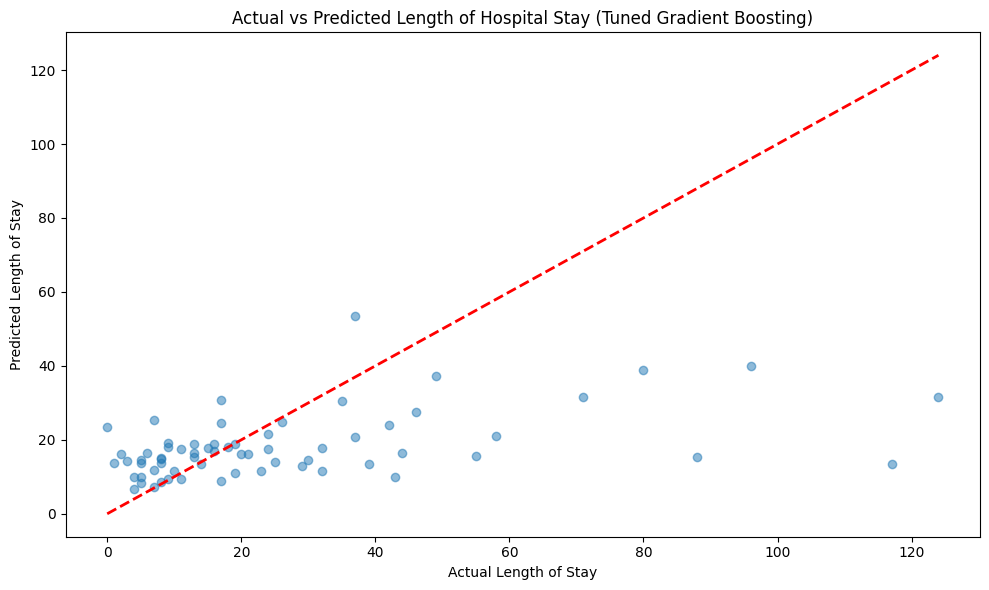

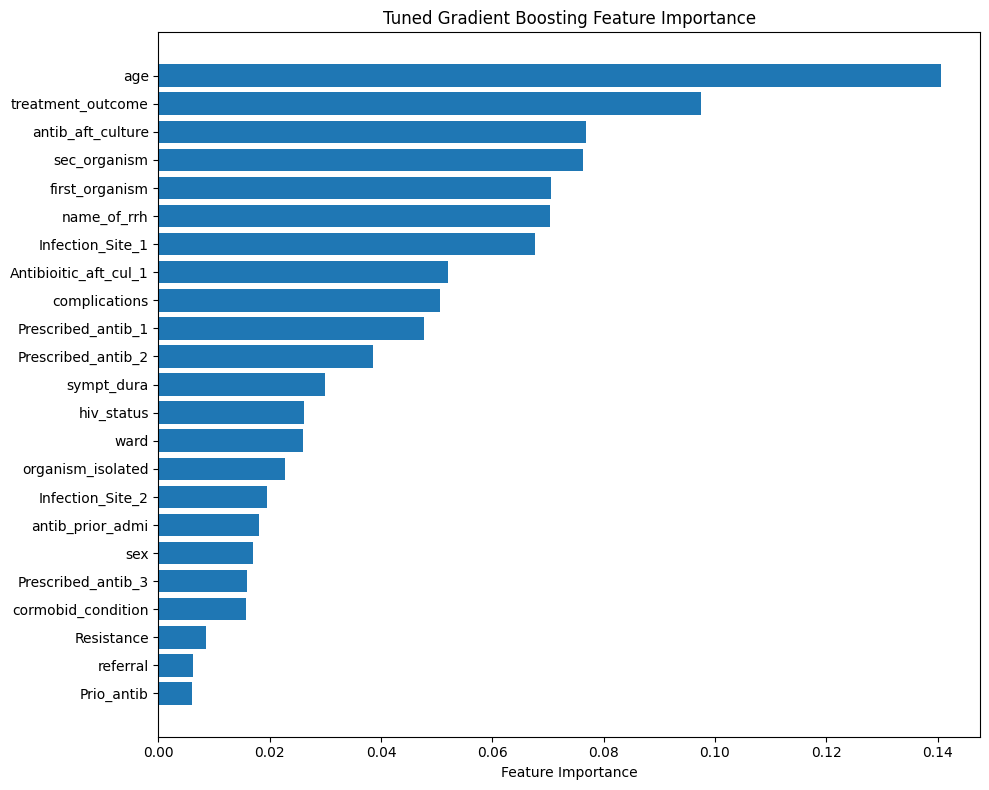

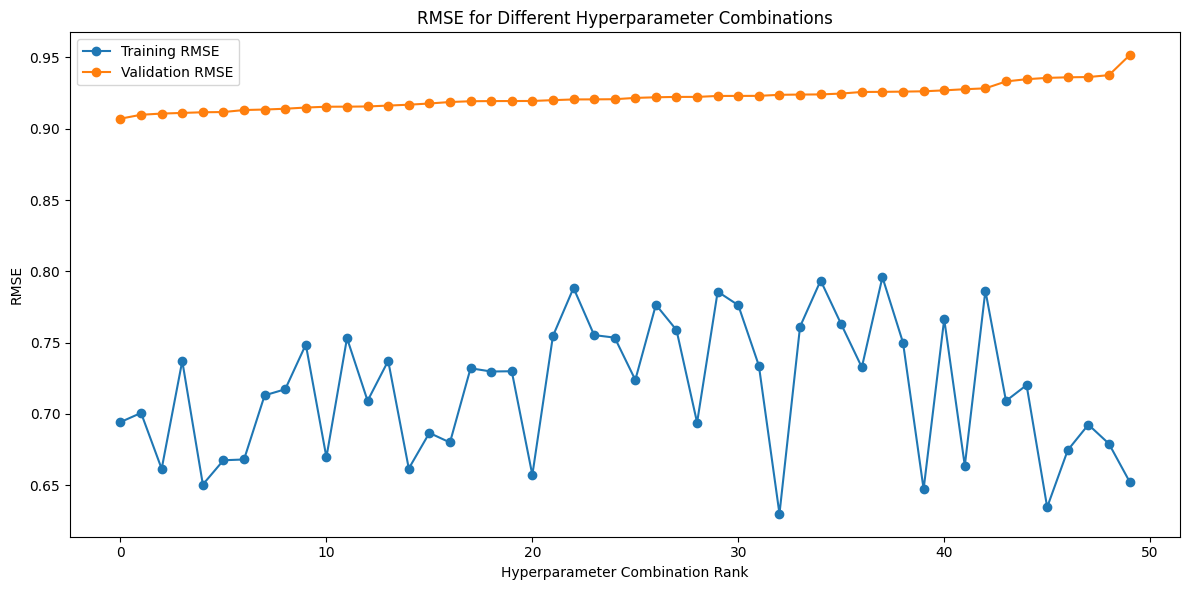

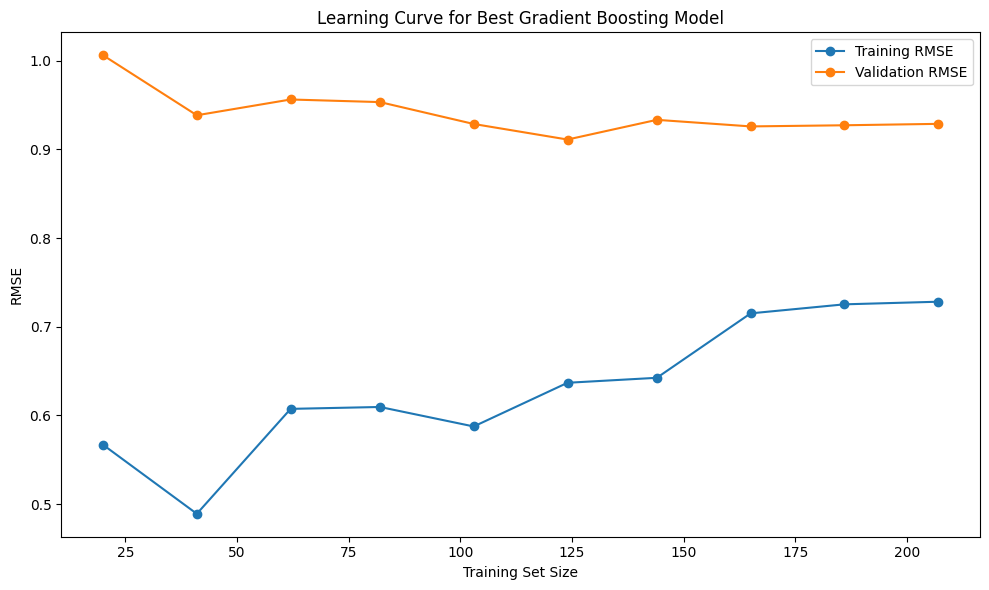

In [ ]:
import mlflow
from mlflow.models import infer_signature
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform

# Apply log transformation to the target variable
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the hyperparameter search space for Gradient Boosting
param_distributions = {
    'n_estimators': randint(1000, 3500),
    'learning_rate': uniform(0.001, 0.01),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 10),
    'subsample': uniform(0.7, 0.3),  # This means from 0.7 to 1.0
    'max_features': uniform(0.5, 0.5),  # This means from 0.5 to 1.0
    'loss': ['ls'],  # Since we're focused on squared error
}

# Initialize the base model
base_model = GradientBoostingRegressor(
    random_state=10,
    validation_fraction=0.2,
    n_iter_no_change=50,
    tol=1e-5
)

# Set up cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings sampled
    cv=cv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,  # Use all available processors
    verbose=2,
    return_train_score=True
)

# Perform the randomized search
print("Starting hyperparameter tuning with RandomizedSearchCV...")
random_search.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found:")
print(random_search.best_params_)
print(f"Best RMSE: {np.sqrt(-random_search.best_score_)}")

# Get the best model
best_gb = random_search.best_estimator_

# Make predictions and inverse transform them
y_pred_log = best_gb.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the best model and metrics with MLflow
with mlflow.start_run():
    # Log best parameters
    mlflow.log_params(random_search.best_params_)
    
    # Log metrics
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(best_gb, "best_GB_regressor_model", signature=signature)

# Print the metrics
print("\nFinal Model Performance on Test Set:")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Create a scatter plot to visualize predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Tuned Gradient Boosting)')
plt.tight_layout()
plt.savefig('gb_predictions_vs_actual.png')
plt.show()

# Feature importance plot for the best model
feature_importance = best_gb.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Tuned Gradient Boosting Feature Importance')
plt.tight_layout()
plt.savefig('gb_feature_importance.png')
plt.show()

# Plot learning curves of the hyperparameter search
results = random_search.cv_results_
plt.figure(figsize=(12, 6))

# Get indices sorted by rank
sorted_indices = np.argsort(results['rank_test_score'])

# Plot the RMSE for each hyperparameter combination
train_scores = -results['mean_train_score'][sorted_indices]
test_scores = -results['mean_test_score'][sorted_indices]
plt.plot(range(len(sorted_indices)), np.sqrt(train_scores), 'o-', label='Training RMSE')
plt.plot(range(len(sorted_indices)), np.sqrt(test_scores), 'o-', label='Validation RMSE')
plt.xlabel('Hyperparameter Combination Rank')
plt.ylabel('RMSE')
plt.title('RMSE for Different Hyperparameter Combinations')
plt.legend()
plt.tight_layout()
plt.savefig('gb_hyperparameter_search_results.png')
plt.show()

# Optional: Plot learning curve of the best model
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    best_gb, X_train, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Calculate RMSE from MSE
train_rmse = np.sqrt(-np.mean(train_scores, axis=1))
valid_rmse = np.sqrt(-np.mean(valid_scores, axis=1))

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse, 'o-', label='Training RMSE')
plt.plot(train_sizes, valid_rmse, 'o-', label='Validation RMSE')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title('Learning Curve for Best Gradient Boosting Model')
plt.legend()
plt.tight_layout()
plt.savefig('gb_learning_curve.png')
plt.show()

# Light gbm regressor

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.118161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 259, number of used features: 23
[LightGBM] [Info] Start training from score 2.905777
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run magnificent-kit-684 at: http://127.0.0.1:8080/#/experiments/442355567818203334/runs/1c262cd904204ae2950fa0f2712c9de5
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/442355567818203334
Mean Absolute Error: 15.84
Root Mean Squared Error: 26.32
R-squared Score: 0.0371


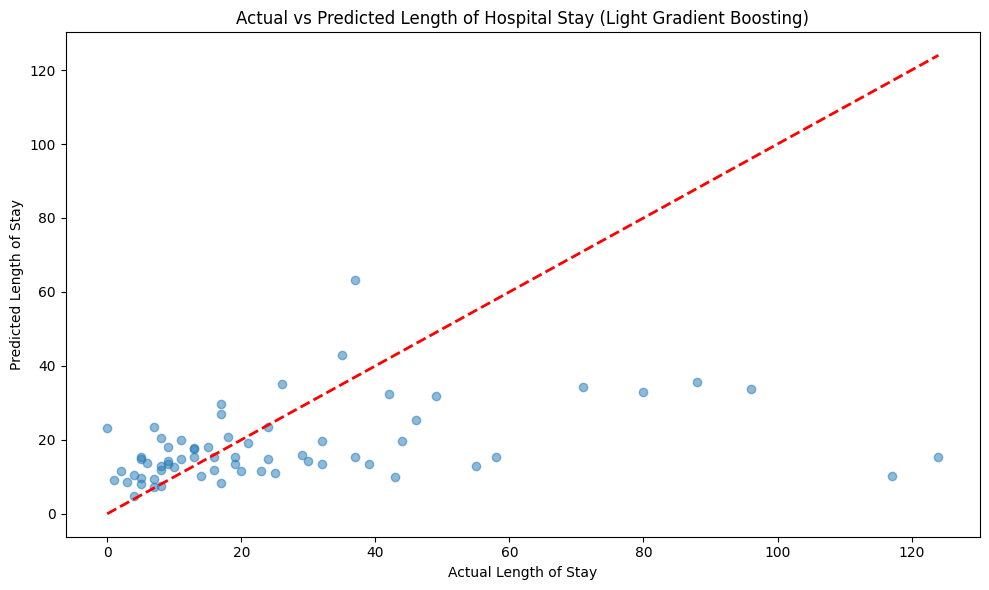

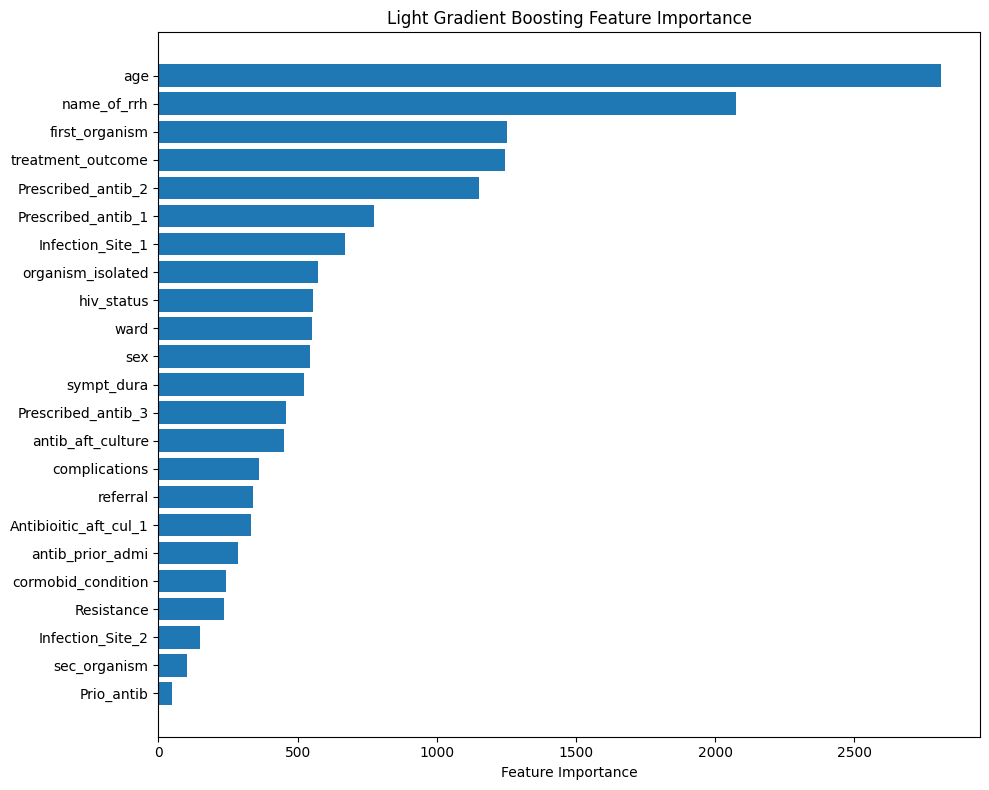

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Apply log transformation to the target variable
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters for Light Gradient Boosting
params = {
    'objective' : 'regression',
    'random_state': 10,
    'n_estimators': 2500,         # Significantly increased for better fit
    'learning_rate': 0.005,       # Further reduced for more precise corrections
    'max_depth': 4,               # Increased to capture more complex patterns
    'num_leaves': 85, 
    'boosting_type' : 'gbdt',
    'subsample_for_bin'  : 25000               
}

# Initialize and train the Light Gradient Boosting Regressor
lgbm = LGBMRegressor(**params)
lgbm.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = lgbm.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(lgbm, "LGBM_regressor_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
          [y_test_original.min(), y_test_original.max()],
          'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Light Gradient Boosting)')
plt.tight_layout()
plt.show()

# Feature importance plot
feature_importance = lgbm.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Light Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow LGBM Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "LGBM_regressor_model")

    # Infer the model signature
    signature = infer_signature(X_train, lgbm.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="LGBM Regressor model",
    )

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'LGBM Regressor model' already exists. Creating a new version of this model...
2025/02/27 15:41:34 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creat

🏃 View run big-ray-220 at: http://127.0.0.1:8080/#/experiments/822887533196691341/runs/6bd883547af141a38c37929f42ac2555
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/822887533196691341


Created version '8' of model 'LGBM Regressor model'.


In [ ]:
import optuna

# Ensure growth is defined
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])  

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define objective function for Optuna
def objective(trial):
    params = {
        'objective': 'regression',
        'boosting_type': 'gbdt',
        'random_state': 10,
        'n_estimators': trial.suggest_int('n_estimators', 1000, 3000, step=500),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.02, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150, step=10),
        'subsample_for_bin': trial.suggest_int('subsample_for_bin', 20000, 50000, step=5000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50, step=5),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }

    # Train model
    lgbm = LGBMRegressor(**params)
    lgbm.fit(X_train, y_train, eval_set=[(X_test, y_test)])
    
    # Predict and evaluate
    y_pred_log = lgbm.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test)
    
    mae = mean_absolute_error(y_test_original, y_pred)
    return mae  # Minimizing MAE

# Run Optuna optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# Get best hyperparameters
best_params = study.best_params
print("Best hyperparameters:", best_params)

# Train final model with best parameters
lgbm_final = LGBMRegressor(**best_params)
lgbm_final.fit(X_train, y_train)

# Evaluate on test set
y_pred_log = lgbm_final.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log best model with MLflow
with mlflow.start_run():
    mlflow.log_params(best_params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(lgbm_final, "LGBM_regressor_optimized")

# Print final metrics
print(f"Optimized Mean Absolute Error: {mae:.2f}")
print(f"Optimized Root Mean Squared Error: {rmse:.2f}")
print(f"Optimized R-squared Score: {r2:.4f}")

[I 2025-02-27 15:41:34,762] A new study created in memory with name: no-name-e67344c1-8789-4385-9f4b-ae9620efd942


[LightGBM] [Warning] lambda_l2 is set=1.5557865915483212e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.5557865915483212e-06
[LightGBM] [Warning] lambda_l1 is set=0.02858455462037866, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.02858455462037866
[LightGBM] [Warning] lambda_l2 is set=1.5557865915483212e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.5557865915483212e-06
[LightGBM] [Warning] lambda_l1 is set=0.02858455462037866, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.02858455462037866
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 259, number of used features: 19
[LightGBM] [Warning] lambda_l2 is set=1.5557865915483212e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.5557865915483212e-06
[LightGBM] [Warnin

[I 2025-02-27 15:41:41,225] Trial 0 finished with value: 15.82818158786128 and parameters: {'n_estimators': 2500, 'learning_rate': 0.004254639908894888, 'max_depth': 9, 'num_leaves': 150, 'subsample_for_bin': 25000, 'min_child_samples': 45, 'lambda_l1': 0.02858455462037866, 'lambda_l2': 1.5557865915483212e-06}. Best is trial 0 with value: 15.82818158786128.


[LightGBM] [Warning] lambda_l2 is set=1.5557865915483212e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.5557865915483212e-06
[LightGBM] [Warning] lambda_l1 is set=0.02858455462037866, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.02858455462037866
[LightGBM] [Warning] lambda_l2 is set=6.139048081903227, reg_lambda=0.0 will be ignored. Current value: lambda_l2=6.139048081903227
[LightGBM] [Warning] lambda_l1 is set=0.024660228246993484, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.024660228246993484
[LightGBM] [Warning] lambda_l2 is set=6.139048081903227, reg_lambda=0.0 will be ignored. Current value: lambda_l2=6.139048081903227
[LightGBM] [Warning] lambda_l1 is set=0.024660228246993484, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.024660228246993484
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019375 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not en

[I 2025-02-27 15:41:45,019] Trial 1 finished with value: 15.329297055521526 and parameters: {'n_estimators': 2000, 'learning_rate': 0.0037158023847729048, 'max_depth': 7, 'num_leaves': 50, 'subsample_for_bin': 45000, 'min_child_samples': 50, 'lambda_l1': 0.024660228246993484, 'lambda_l2': 6.139048081903227}. Best is trial 1 with value: 15.329297055521526.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-02-27 15:44:14,947] Trial 49 finished with value: 15.392904827296661 and parameters: {'n_estimators': 1500, 'learning_rate': 0.007843757238404499, 'max_depth': 3, 'num_leaves': 50, 'subsample_for_bin': 25000, 'min_child_samples': 20, 'lambda_l1': 0.0016321113533240856, 'lambda_l2': 0.03465588668462098}. Best is trial 40 with value: 15.096630397432284.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

2025/02/27 15:44:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run mysterious-trout-139 at: http://127.0.0.1:8080/#/experiments/822887533196691341/runs/f0e237dff8f2493cb24c03624d33a49e
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/822887533196691341
Optimized Mean Absolute Error: 15.10
Optimized Root Mean Squared Error: 25.27
Optimized R-squared Score: 0.1121


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Selection and Training
# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# XGBoost Regressor
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

# Model Evaluation
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, r2

rf_mae, rf_mse, rf_r2 = evaluate_model(rf_model, X_test, y_test)
xgb_mae, xgb_mse, xgb_r2 = evaluate_model(xgb_model, X_test, y_test)

print(f"Random Forest - MAE: {rf_mae}, MSE: {rf_mse}, R2: {rf_r2}")
print(f"XGBoost - MAE: {xgb_mae}, MSE: {xgb_mse}, R2: {xgb_r2}")

# Hyperparameter Tuning (Example for XGBoost)
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_xgb_model = grid_search.best_estimator_
best_xgb_mae, best_xgb_mse, best_xgb_r2 = evaluate_model(best_xgb_model, X_test, y_test)

print(f"Best XGBoost - MAE: {best_xgb_mae}, MSE: {best_xgb_mse}, R2: {best_xgb_r2}")

Random Forest - MAE: 0.6564919333135588, MSE: 0.7010507190918802, R2: 0.25929767708261353
XGBoost - MAE: 0.6475692399524526, MSE: 0.679212448806502, R2: 0.28237112539150455
Best XGBoost - MAE: 0.6447454344513897, MSE: 0.684910109334236, R2: 0.2763512037607928


# Extreme gradient boost

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run trusting-bat-423 at: http://127.0.0.1:8080/#/experiments/822887533196691341/runs/8b0f71be141845a8881ba4881fb6fcdd
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/822887533196691341
Mean Absolute Error: 15.07
Root Mean Squared Error: 25.19
R-squared Score: 0.1180


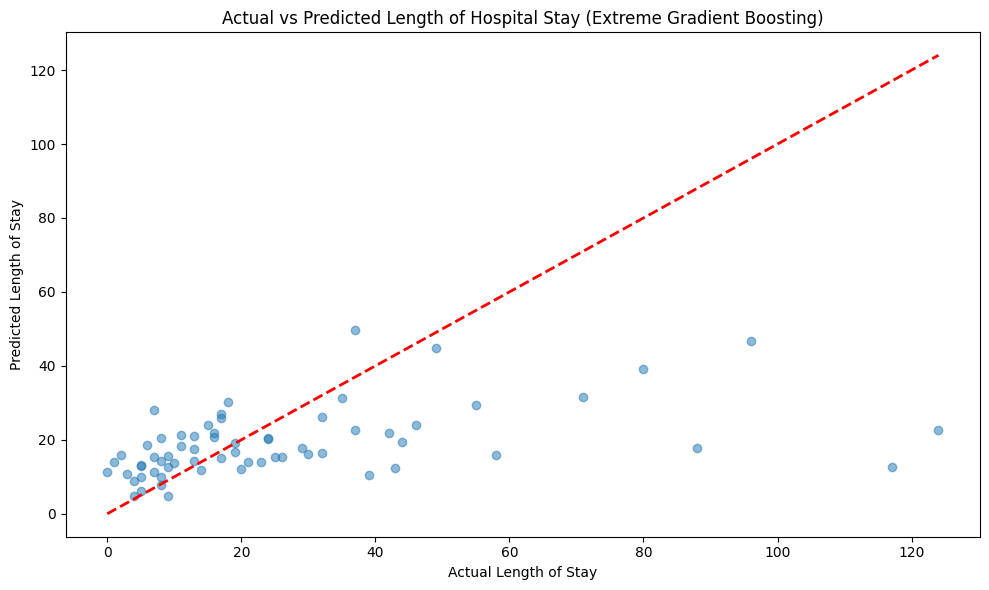

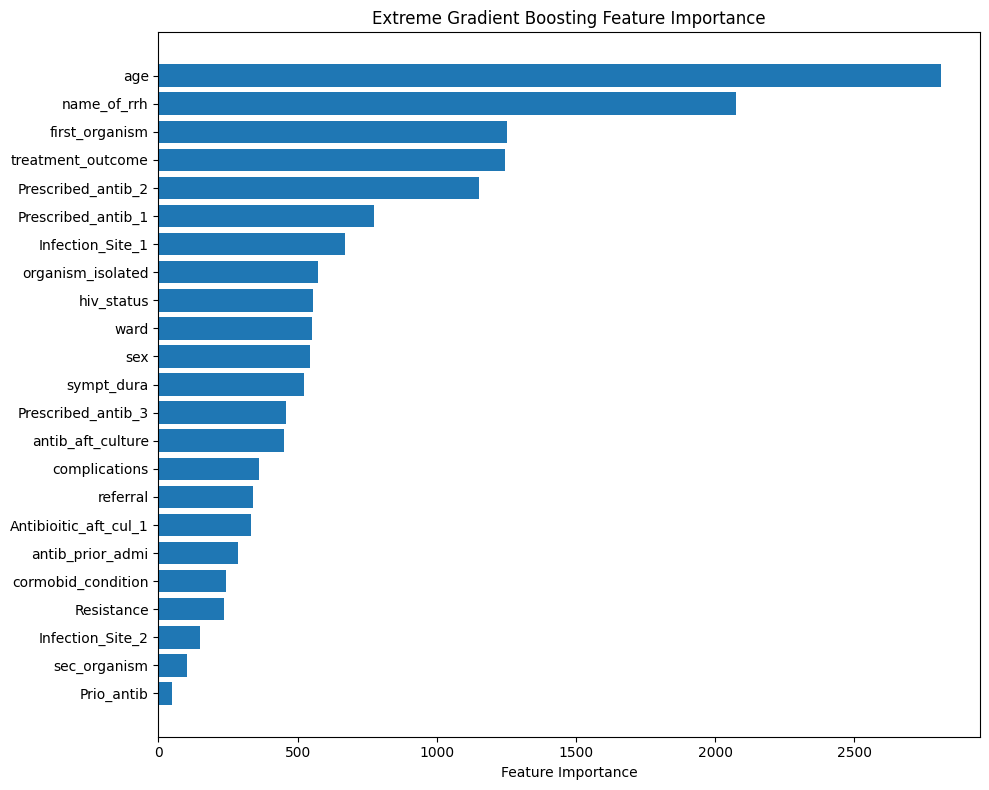

In [ ]:
1

In [ ]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow XGB Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "XGB_regressor_model")

    # Infer the model signature
    signature = infer_signature(X_train, lgbm.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="XGB Regressor model",
    )

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'XGB Regressor model' already exists. Creating a new version of this model...
2025/02/27 15:45:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creati

🏃 View run traveling-elk-463 at: http://127.0.0.1:8080/#/experiments/317490332836945887/runs/cdb80bdcd4ee45ada6f1c1b90858cfed
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/317490332836945887


# Lasso Elastic Regressor

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run dazzling-mule-304 at: http://127.0.0.1:8080/#/experiments/630657385198661799/runs/41b78bb3afc344a68ce156981b24ed21
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/630657385198661799
Mean Absolute Error: 15.59
Root Mean Squared Error: 26.21
R-squared Score: 0.0449


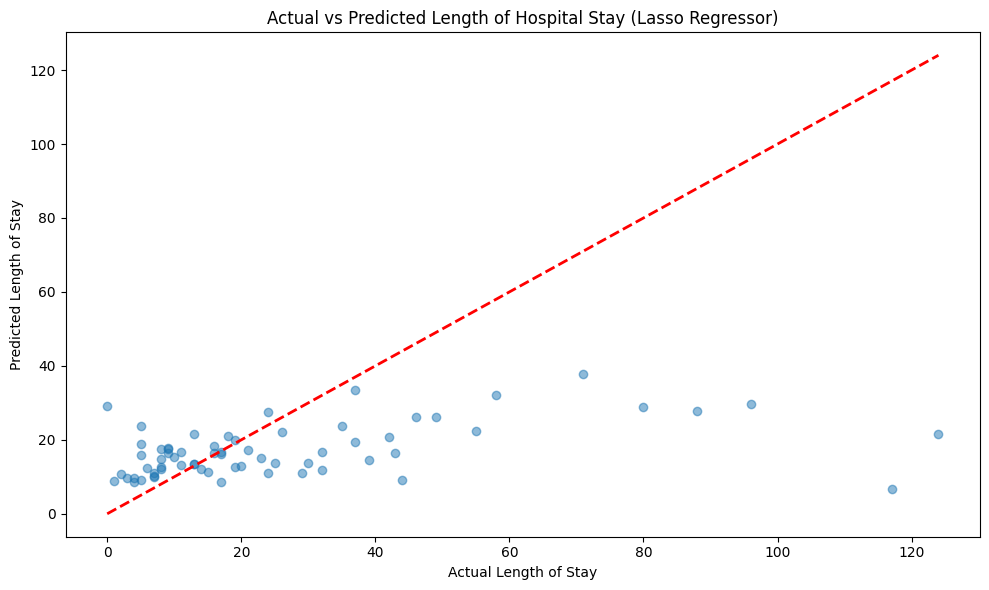

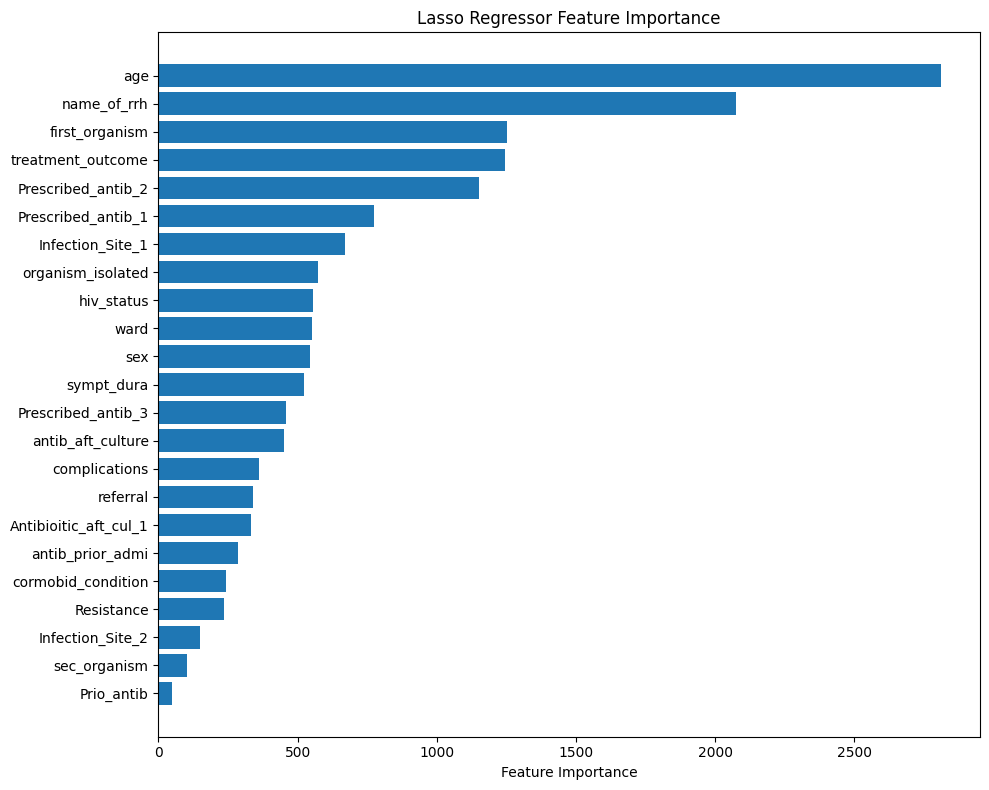

In [ ]:
from sklearn.linear_model import Lasso

# Apply log transformation to the target variable
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters for Light Gradient Boosting
params = {
    'random_state':10,
    'alpha' : 00.006551,
    'fit_intercept' : True,
    'copy_X' : True,
    'max_iter' : 1500,
    'positive' : True
}


# Initialize and train the Light Gradient Boosting Regressor
lasso = Lasso(**params)
lasso.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = lasso.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(xgb, "Lasso_regressor_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
          [y_test_original.min(), y_test_original.max()],
          'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Lasso Regressor)')
plt.tight_layout()
plt.show()

# Feature importance plot
feature_importance = lgbm.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Lasso Regressor Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow Lasso Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Lasso_regressor_model")

    # Infer the model signature
    signature = infer_signature(X_train, lgbm.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="Lasso Regressor model",
    )

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'Lasso Regressor model' already exists. Creating a new version of this model...
2025/02/27 16:00:27 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish crea

🏃 View run angry-mole-846 at: http://127.0.0.1:8080/#/experiments/630657385198661799/runs/b11988cd1b364b7bbee21844df212ca7
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/630657385198661799


Created version '5' of model 'Lasso Regressor model'.


Best alpha from cross-validation: 0.006551
CV Mean Absolute Error: 0.7088 ± 0.0876
CV Root Mean Squared Error: 0.9118 ± 0.1095
CV R-squared Score: 0.0580 ± 0.1368


/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run monumental-mole-832 at: http://127.0.0.1:8080/#/experiments/630657385198661799/runs/01d5886ea9ca40aca6e36e2106405132
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/630657385198661799
Test Mean Absolute Error: 15.59
Test Root Mean Squared Error: 26.21
Test R-squared Score: 0.0449


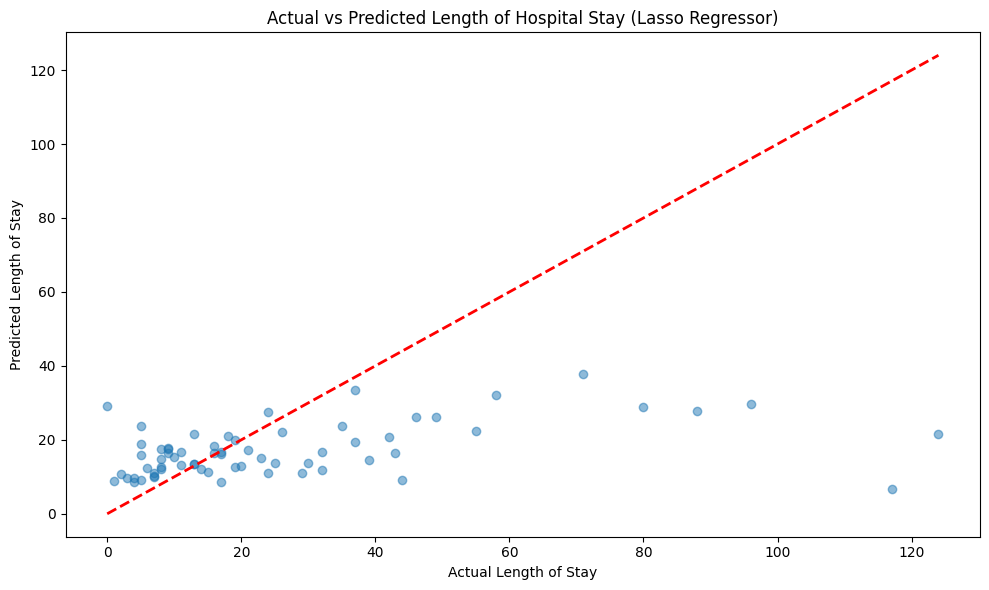

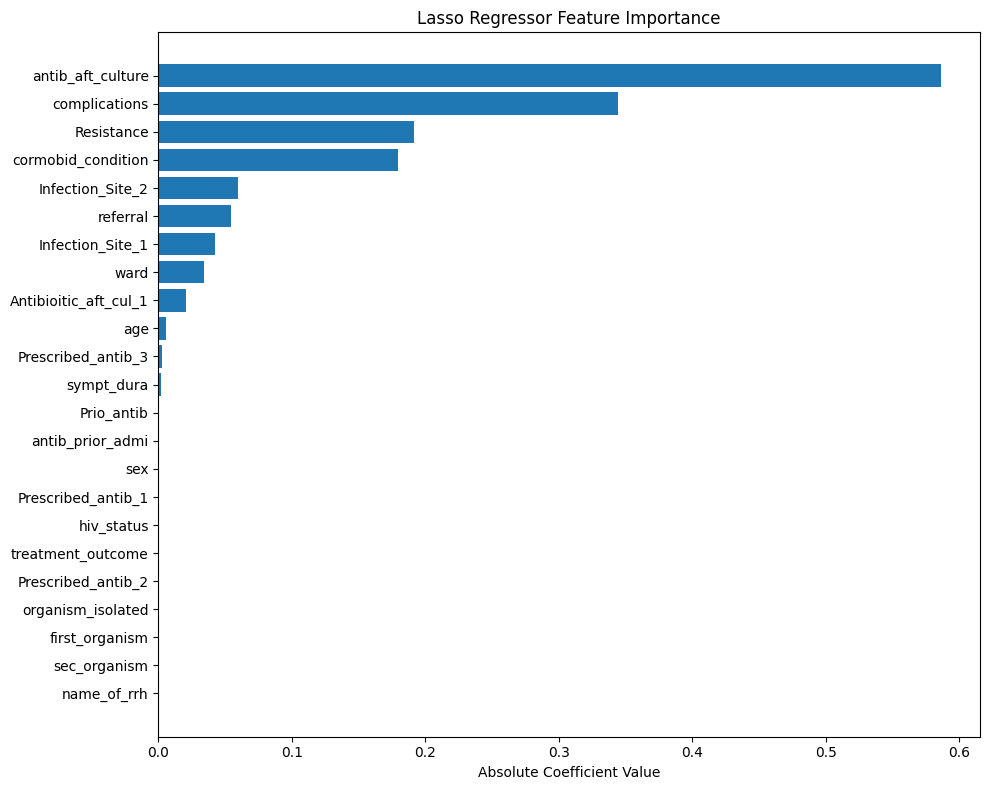

In [ ]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# Apply log transformation to the target variable
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1. First approach: Cross-validation to find optimal alpha
alphas = np.logspace(-3, 1, 50)  # Range of alphas to test
lasso_cv = LassoCV(
    alphas=alphas,
    cv=25,
    random_state=10,
    max_iter=1500,
    positive=True,
    fit_intercept=True
)

# Fit the model
lasso_cv.fit(X_train, y_train)

# Get the best alpha
best_alpha = lasso_cv.alpha_
print(f"Best alpha from cross-validation: {best_alpha:.6f}")

# 2. Second approach: Cross-validation for model evaluation
params = {
    'random_state': 10,
    'alpha': best_alpha,  # Use the best alpha found
    'fit_intercept': True,
    'copy_X': True,
    'max_iter': 1500,
    'positive': True
}

# Initialize the model with the best parameters
lasso = Lasso(**params)

# Setup cross-validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Cross-validate and evaluate
cv_mae = -cross_val_score(lasso, X_train, y_train, cv=cv, 
                         scoring='neg_mean_absolute_error', n_jobs=-1)
cv_rmse = np.sqrt(-cross_val_score(lasso, X_train, y_train, cv=cv, 
                                 scoring='neg_mean_squared_error', n_jobs=-1))
cv_r2 = cross_val_score(lasso, X_train, y_train, cv=cv, 
                       scoring='r2', n_jobs=-1)

# Print cross-validation results
print(f"CV Mean Absolute Error: {cv_mae.mean():.4f} ± {cv_mae.std():.4f}")
print(f"CV Root Mean Squared Error: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"CV R-squared Score: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# Train the final model with the best parameters on the full training set
final_lasso = Lasso(**params)
final_lasso.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = final_lasso.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("best_alpha", best_alpha)
    mlflow.log_metric("cv_mae_mean", cv_mae.mean())
    mlflow.log_metric("cv_rmse_mean", cv_rmse.mean())
    mlflow.log_metric("cv_r2_mean", cv_r2.mean())
    mlflow.log_metric("test_mae", mae)
    mlflow.log_metric("test_mse", mse)
    mlflow.log_metric("test_rmse", rmse)
    mlflow.log_metric("test_r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred_log)
    mlflow.sklearn.log_model(final_lasso, "Lasso_regressor_model", signature=signature)

# Print the test metrics
print(f"Test Mean Absolute Error: {mae:.2f}")
print(f"Test Root Mean Squared Error: {rmse:.2f}")
print(f"Test R-squared Score: {r2:.4f}")

# Scatter plot for predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay (Lasso Regressor)')
plt.tight_layout()
plt.show()

# Feature importance plot for Lasso using absolute coefficient values
feature_importance = np.abs(final_lasso.coef_)
feature_names = X.columns
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
plt.xlabel('Absolute Coefficient Value')
plt.title('Lasso Regressor Feature Importance')
plt.tight_layout()
plt.show()